# Generate data, lesioning load-tuned neurons

firing rates, LFP, behavior

run after filtering down the models using filter_models_multiload.ipynb (in 0_behavior/1_model_performance folder)  

FOR EACH MODEL
1. find neurons that are load-tuned
2. for each load tuning (ie 1, 3):
    1. lesion outgoing connections by 50% for those neurons preferring that load
    2. generate data for a balanced combo of trials
3. study performance

In [1]:
%matplotlib inline
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis')
import generate_rate_data_multiload as grdm
import os
import numpy as np
from matplotlib import pyplot as plt

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld
import rate_neuron_utils as rn

2026-06-30 16:47:56.098371: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-30 16:47:56.106239: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-30 16:47:56.114900: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-30 16:47:56.117518: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-30 16:47:56.124627: I tensorflow/core/platform/cpu_feature_guar

## delay=150, lesion load-selective

In [2]:
settings =  {
    "T": 450,
    "stim_on": 50,
    "stim_dur": 25,
    # "delay": 200,
    "delay": 150,
    "DeltaT": 1,
    "taus": 20,
    "fs": 200,
    "task": "sternberg",
    "load": 1,
}

### necessary functions

#### funcs

In [3]:
from itertools import permutations
import random
from collections import Counter

def generate_sternberg_trialtypes_load3(stimuli, memory_set_size=3, shuffle=False, n_repeats=1, seed=None):
    """
    Generate a Sternberg block balanced on:
      - Match vs mismatch (50/50)
      - All ordered memory sequences (permutations, not combinations)
      - Serial position of match probe (each position probed once per sequence)
      - Stimulus identity as match and mismatch probe
    
    Block size: 2 * P(n,k) * k = 2 * 24 * 3 = 144 trials (for 4 stimuli, set size 3)
    Output shape: (n_trials, 6) — columns: [load, match, stim1, stim2, stim3, probe]
                                           match: 1 = match, -1 = mismatch
    """
    if seed is not None:
        random.seed(seed)

    seqs = list(permutations(stimuli, memory_set_size))
    trial_type_all = []

    for _ in range(n_repeats):
        for seq in seqs:
            seq = list(seq)
            excluded = [x for x in stimuli if x not in seq]
            assert len(excluded) == 1
            mismatch_probe = excluded[0]

            for pos in range(memory_set_size):
                trial_type_all.append([memory_set_size,  1] + seq + [seq[pos]])        # match
                trial_type_all.append([memory_set_size, -1] + seq + [mismatch_probe])  # mismatch

    if shuffle:
        random.shuffle(trial_type_all)

    return np.array(trial_type_all)  # shape: (n_trials, 6)

In [4]:
def generate_sternberg_trialtypes_load1(stimuli, memory_set_size=1, shuffle=False, n_repeats=1, seed=None):
    """
    Generate a load-1 Sternberg block with all possible trial combinations, balanced on:
      - Match vs mismatch (50/50)
      - All ordered memory sequences (permutations of size 1)
      - All possible mismatch probes for each sequence

    For load 1: 
      - 4 unique match trials (each stimulus shown and probed once)
      - 12 unique mismatch trials (4 sequences x 3 excluded stimuli)
      - Each match trial repeated 3x to achieve 50/50 balance
      - Total: 24 trials per repeat

    Output shape: (n_trials, 6) — columns: [load, match, stim1, stim2, stim3, probe]
                                            stim2, stim3 = NaN (unused at load 1)
                                            match: 1 = match, -1 = mismatch
    """
    if seed is not None:
        random.seed(seed)

    seqs = list(permutations(stimuli, memory_set_size))  # 4 single-element sequences
    trials = []

    for _ in range(n_repeats):
        for seq in seqs:
            seq = list(seq)
            excluded = [x for x in stimuli if x not in seq]  # 3 excluded stimuli

            # All 3 mismatch probes for this sequence
            for mismatch_probe in excluded:
                trials.append([memory_set_size,  1] + seq + [float('nan'), float('nan')] + [seq[0]])          # match (repeated 3x across excluded loop)
                trials.append([memory_set_size, -1] + seq + [float('nan'), float('nan')] + [mismatch_probe])  # mismatch

    if shuffle:
        random.shuffle(trials)

    return np.array(trials, dtype=float)  # shape: (n_trials, 6)

In [5]:
def generate_u_from_trialtypes(trial_type_all, settings):
    """
    Generate input u from trial_type_all.
    """
    n_trials = trial_type_all.shape[0]
    
    t_total = int(settings["T"])
    stim_on = int(settings["stim_on"])
    stim_dur = int(settings["stim_dur"])
    delay = int(settings["delay"])
    
    n_channels = 4
    u_all = np.zeros((n_trials, n_channels, settings["T"]), dtype=np.float32)  # shape: (n_trials, T, n_channels)
    
    for i_trial in range(n_trials):
        u = np.zeros((n_channels, t_total), dtype=np.float32)
        stim_chan_idx = trial_type_all[i_trial, 2:-1] # stim channels are in columns 2 to -1 (excluding last column which is probe)
        stim_chan_idx = stim_chan_idx[~np.isnan(stim_chan_idx)].astype(int) # remove possible nan's from stim_chan_idx (in case of lower load)
        probe_chan_idx = trial_type_all[i_trial, -1].astype(int)
        
        for i, i_chan in enumerate(stim_chan_idx):
            if i == 0:
                u[i_chan, stim_on:stim_on+stim_dur] = 1
                ending_idx = stim_on+stim_dur
            else: # 0 bc no separation btwn stimuli
                u[i_chan, ending_idx+0:ending_idx+stim_dur+0] = 1
                ending_idx = ending_idx+stim_dur+0
        
        u[probe_chan_idx, ending_idx+delay:ending_idx+delay+stim_dur] = 1
        u_all[i_trial] = u

    return u_all

#### checks

In [17]:
# a check - for load3
from collections import Counter

# --- Run it ---
stimuli = [0, 1, 2, 3]
memory_set_size = 3

trial_type_all = generate_sternberg_trialtypes_load3(stimuli, shuffle=False, n_repeats=3, seed=42)
# block shape: (n_trials, 6) — columns: [load, match, stim1, stim2, stim3, probe]

# Derive match/mismatch: probe is in the memory set
is_match = np.array([trial_type_all[i, 5] in trial_type_all[i, 2:5] for i in range(len(trial_type_all))])

print(f"Total trials: {len(trial_type_all)}\n")
for i in range(min(12, len(trial_type_all))):
    mem = trial_type_all[i, 2:5].tolist()
    probe = trial_type_all[i, 5]
    trial_type = "match" if is_match[i] else "mismatch"
    print(f"Trial {i+1:3d}: Memory={mem}  Probe={probe}  ({trial_type})")
print(f"  ... ({len(trial_type_all) - 12} more trials)")

# --- Balance checks ---
match_trials    = trial_type_all[is_match]
mismatch_trials = trial_type_all[~is_match]

print(f"\n--- Balance Check ---")
print(f"Match trials:    {len(match_trials)}")
print(f"Mismatch trials: {len(mismatch_trials)}")

print(f"\nMatch probe identity:    {Counter(match_trials[:, 5].tolist())}")
print(f"Mismatch probe identity: {Counter(mismatch_trials[:, 5].tolist())}")

print(f"\nMatch probe by serial position:")
for pos in range(memory_set_size):
    at_pos = match_trials[match_trials[:, pos] == match_trials[:, 5]]
    print(f"  Position {pos}: {Counter(at_pos[:, 5].tolist())}")

print(f"\nUnique ordered memory sequences (match):    "
      f"{len(set(map(tuple, match_trials[:, 2:5].tolist())))}")
print(f"Unique ordered memory sequences (mismatch): "
      f"{len(set(map(tuple, mismatch_trials[:, 2:5].tolist())))}")

Total trials: 432

Trial   1: Memory=[0, 1, 2]  Probe=0  (match)
Trial   2: Memory=[0, 1, 2]  Probe=3  (mismatch)
Trial   3: Memory=[0, 1, 2]  Probe=1  (match)
Trial   4: Memory=[0, 1, 2]  Probe=3  (mismatch)
Trial   5: Memory=[0, 1, 2]  Probe=2  (match)
Trial   6: Memory=[0, 1, 2]  Probe=3  (mismatch)
Trial   7: Memory=[0, 1, 3]  Probe=0  (match)
Trial   8: Memory=[0, 1, 3]  Probe=2  (mismatch)
Trial   9: Memory=[0, 1, 3]  Probe=1  (match)
Trial  10: Memory=[0, 1, 3]  Probe=2  (mismatch)
Trial  11: Memory=[0, 1, 3]  Probe=3  (match)
Trial  12: Memory=[0, 1, 3]  Probe=2  (mismatch)
  ... (420 more trials)

--- Balance Check ---
Match trials:    216
Mismatch trials: 216

Match probe identity:    Counter({0: 54, 1: 54, 2: 54, 3: 54})
Mismatch probe identity: Counter({3: 54, 2: 54, 1: 54, 0: 54})

Match probe by serial position:
  Position 0: Counter({3: 54})
  Position 1: Counter({1: 54})
  Position 2: Counter({0: 18, 1: 18, 2: 18, 3: 18})

Unique ordered memory sequences (match):    24


In [18]:
trial_type_all.shape

(432, 6)

In [27]:
# a check - for load1
from collections import Counter

# --- Run it ---
stimuli = [0, 1, 2, 3]
memory_set_size = 1

trial_type_all = generate_sternberg_trialtypes_load1(stimuli, shuffle=False, n_repeats=6, seed=42)
# block shape: (n_trials, 6) — columns: [load, match, stim1, stim2, stim3, probe]

# Derive match/mismatch: probe is in the memory set
is_match = np.array([trial_type_all[i, 5] in trial_type_all[i, 2:5] for i in range(len(trial_type_all))])

print(f"Total trials: {len(trial_type_all)}\n")
for i in range(min(12, len(trial_type_all))):
    mem = trial_type_all[i, 2:5].tolist()
    probe = trial_type_all[i, 5]
    trial_type = "match" if is_match[i] else "mismatch"
    print(f"Trial {i+1:3d}: Memory={mem}  Probe={probe}  ({trial_type})")
print(f"  ... ({len(trial_type_all) - 12} more trials)")

# --- Balance checks ---
match_trials    = trial_type_all[is_match]
mismatch_trials = trial_type_all[~is_match]

print(f"\n--- Balance Check ---")
print(f"Match trials:    {len(match_trials)}")
print(f"Mismatch trials: {len(mismatch_trials)}")

print(f"\nMatch probe identity:    {Counter(match_trials[:, 5].tolist())}")
print(f"Mismatch probe identity: {Counter(mismatch_trials[:, 5].tolist())}")

print(f"\nMatch probe by serial position:")
for pos in range(memory_set_size):
    at_pos = match_trials[match_trials[:, pos] == match_trials[:, 5]]
    print(f"  Position {pos}: {Counter(at_pos[:, 5].tolist())}")

print(f"\nUnique ordered memory sequences (match):    "
      f"{len(set(map(tuple, match_trials[:, 2:5].tolist())))}")
print(f"Unique ordered memory sequences (mismatch): "
      f"{len(set(map(tuple, mismatch_trials[:, 2:5].tolist())))}")

Total trials: 144

Trial   1: Memory=[0.0, nan, nan]  Probe=0.0  (match)
Trial   2: Memory=[0.0, nan, nan]  Probe=1.0  (mismatch)
Trial   3: Memory=[0.0, nan, nan]  Probe=0.0  (match)
Trial   4: Memory=[0.0, nan, nan]  Probe=2.0  (mismatch)
Trial   5: Memory=[0.0, nan, nan]  Probe=0.0  (match)
Trial   6: Memory=[0.0, nan, nan]  Probe=3.0  (mismatch)
Trial   7: Memory=[1.0, nan, nan]  Probe=1.0  (match)
Trial   8: Memory=[1.0, nan, nan]  Probe=0.0  (mismatch)
Trial   9: Memory=[1.0, nan, nan]  Probe=1.0  (match)
Trial  10: Memory=[1.0, nan, nan]  Probe=2.0  (mismatch)
Trial  11: Memory=[1.0, nan, nan]  Probe=1.0  (match)
Trial  12: Memory=[1.0, nan, nan]  Probe=3.0  (mismatch)
  ... (132 more trials)

--- Balance Check ---
Match trials:    72
Mismatch trials: 72

Match probe identity:    Counter({0.0: 18, 1.0: 18, 2.0: 18, 3.0: 18})
Mismatch probe identity: Counter({1.0: 18, 2.0: 18, 3.0: 18, 0.0: 18})

Match probe by serial position:
  Position 0: Counter({1.0: 18})

Unique ordered mem

In [28]:
trial_type_load3 = generate_sternberg_trialtypes_load3(stimuli, shuffle=False, n_repeats=3, seed=42)
trial_type_load1 = generate_sternberg_trialtypes_load1(stimuli, shuffle=False, n_repeats=6, seed=42)

# stack
trial_type_all = np.vstack([trial_type_load3, trial_type_load1])

print(f"Total trials: {len(trial_type_all)}\n")

Total trials: 576



In [35]:
u_all = generate_u_from_trialtypes(trial_type_all, settings)
print(f"u_all shape: {u_all.shape}")

u_all shape: (576, 4, 450)


In [45]:
# do a bunch of printing for good measure

print(f"n load1 trials: {np.sum(trial_type_all[:, 0] == 1)}")
print(f"n load3 trials: {np.sum(trial_type_all[:, 0] == 3)}")

print(f"n match load1 trials: {np.sum((trial_type_all[:, 0] == 1) & (trial_type_all[:, 1] == 1))}")
print(f"n match load3 trials: {np.sum((trial_type_all[:, 0] == 3) & (trial_type_all[:, 1] == 1))}")

print(f"n non-match load1 trials: {np.sum((trial_type_all[:, 0] == 1) & (trial_type_all[:, 1] == -1))}")
print(f"n non-match load3 trials: {np.sum((trial_type_all[:, 0] == 3) & (trial_type_all[:, 1] == -1))}")

print(f"n stim appearances load1, stim#1: {Counter(trial_type_all[trial_type_all[:, 0] == 1][:, 2].tolist())}")
print(f"n stim appearances load1, probe: {Counter(trial_type_all[trial_type_all[:, 0] == 1][:, 5].tolist())}")

print(f"n stim appearances load3, stim#1: {Counter(trial_type_all[trial_type_all[:, 0] == 3][:, 2].tolist())}")
print(f"n stim appearances load3, stim#2: {Counter(trial_type_all[trial_type_all[:, 0] == 3][:, 3].tolist())}")
print(f"n stim appearances load3, stim#3: {Counter(trial_type_all[trial_type_all[:, 0] == 3][:, 4].tolist())}")
print(f"n stim appearances load3, probe: {Counter(trial_type_all[trial_type_all[:, 0] == 3][:, 5].tolist())}")

# print(f"n unique load1 trials: {len(set(map(tuple, trial_type_all[trial_type_all[:, 0] == 1,2:].tolist())))}")
# print(f"n unique load3 trials: {len(set(map(tuple, trial_type_all[trial_type_all[:, 0] == 3,2:].tolist())))}")


n load1 trials: 144
n load3 trials: 432
n match load1 trials: 72
n match load3 trials: 216
n non-match load1 trials: 72
n non-match load3 trials: 216
n stim appearances load1, stim#1: Counter({0.0: 36, 1.0: 36, 2.0: 36, 3.0: 36})
n stim appearances load1, probe: Counter({0.0: 36, 1.0: 36, 2.0: 36, 3.0: 36})
n stim appearances load3, stim#1: Counter({0.0: 108, 1.0: 108, 2.0: 108, 3.0: 108})
n stim appearances load3, stim#2: Counter({1.0: 108, 2.0: 108, 3.0: 108, 0.0: 108})
n stim appearances load3, stim#3: Counter({2.0: 108, 3.0: 108, 1.0: 108, 0.0: 108})
n stim appearances load3, probe: Counter({0.0: 108, 3.0: 108, 1.0: 108, 2.0: 108})


## lesion by 50%

In [6]:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3'

model_paths = ['Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_041152.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_180002.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_233744.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_023239.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_043128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063647.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_153131.mat']

model_names = [os.path.basename(m)[:-4] for m in model_paths]

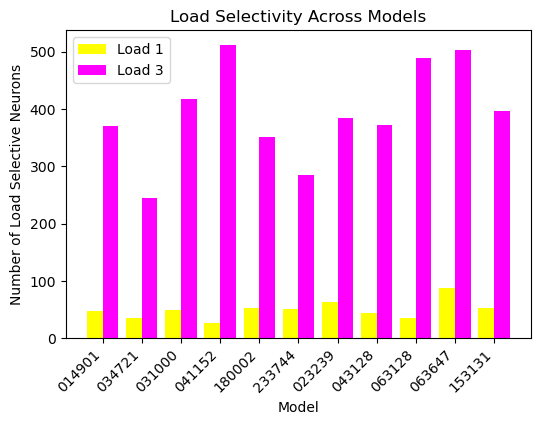

In [7]:
condn_phrase = 'delay'
condn_num=150

n_load1 = []
n_load3 = []
for model_name in model_names[:11]: # start with first 4 models for testing
    
    model_dir = os.path.join(all_models_dir, model_name)
    load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_stims",
                                all_models_dir=all_models_dir)
    load_selective = np.where(~np.isnan(load_tuning))[0]
    load_tuning = load_tuning[load_selective]

    for load in [1,3]: # loads we're testing
        neuron_idxs = load_selective[load_tuning == load] # neuron indices for this specific stimulus
        if load == 1:
            n_load1.append(len(neuron_idxs))
        elif load == 3:
            n_load3.append(len(neuron_idxs))
            
plt.figure(figsize=(6,4))
plt.bar(np.arange(len(n_load1))-0.2, n_load1, width=0.4, label='Load 1', align='center', color='yellow')
plt.bar(np.arange(len(n_load3))+0.2, n_load3, width=0.4, label='Load 3', align='center', color='magenta')
plt.xticks(np.arange(len(n_load1)), [model_name[-6:] for model_name in model_names[:11]], rotation=45, ha='right')
plt.xlabel('Model')
plt.ylabel('Number of Load Selective Neurons')
plt.title('Load Selectivity Across Models')
plt.legend()
plt.show()

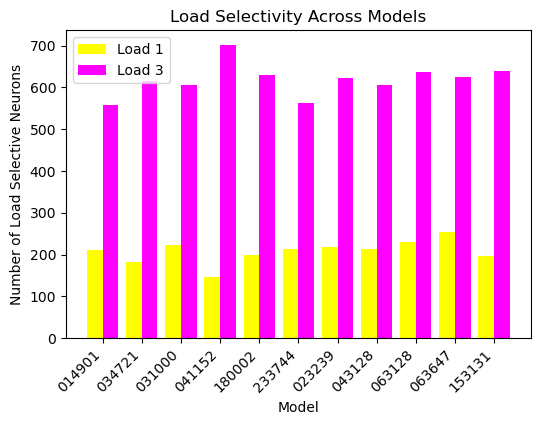

In [25]:
condn_phrase = 'delay'
condn_num=150

n_load1 = []
n_load3 = []
for model_name in model_names[:11]: # start with first 4 models for testing
    
    model_dir = os.path.join(all_models_dir, model_name)
    load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "precomputed.",
                                all_models_dir=all_models_dir)
    load_selective = np.where(~np.isnan(load_tuning))[0]
    load_tuning = load_tuning[load_selective]

    for load in [1,3]: # loads we're testing
        neuron_idxs = load_selective[load_tuning == load] # neuron indices for this specific stimulus
        if load == 1:
            n_load1.append(len(neuron_idxs))
        elif load == 3:
            n_load3.append(len(neuron_idxs))
            
plt.figure(figsize=(6,4))
plt.bar(np.arange(len(n_load1))-0.2, n_load1, width=0.4, label='Load 1', align='center', color='yellow')
plt.bar(np.arange(len(n_load3))+0.2, n_load3, width=0.4, label='Load 3', align='center', color='magenta')
plt.xticks(np.arange(len(n_load1)), [model_name[-6:] for model_name in model_names[:11]], rotation=45, ha='right')
plt.xlabel('Model')
plt.ylabel('Number of Load Selective Neurons')
plt.title('Load Selectivity Across Models')
plt.legend()
plt.show()

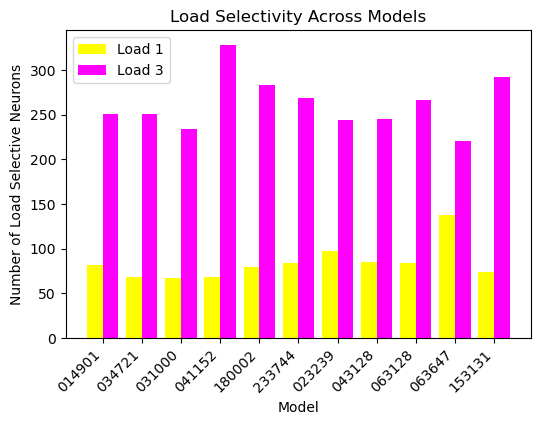

In [27]:
# load-selective but NOT STIM-SELECTIVE

condn_phrase = 'delay'
condn_num=150

n_load1 = []
n_load3 = []
for model_name in model_names[:11]: # start with first 4 models for testing
    
    model_dir = os.path.join(all_models_dir, model_name)
    load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "precomputed.",
                                all_models_dir=all_models_dir)
    load_selective = np.where(~np.isnan(load_tuning))[0]
    stim_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
    stim_nonselective = np.where(np.isnan(stim_tuning))[0]
    load_selective_stimnan = np.intersect1d(load_selective, stim_nonselective)
    load_tuning_selective = load_tuning[load_selective_stimnan]

    for load in [1,3]: # loads we're testing
        neuron_idxs = load_selective_stimnan[load_tuning_selective == load] # neuron indices for this specific stimulus
        if load == 1:
            n_load1.append(len(neuron_idxs))
        elif load == 3:
            n_load3.append(len(neuron_idxs))
            
plt.figure(figsize=(6,4))
plt.bar(np.arange(len(n_load1))-0.2, n_load1, width=0.4, label='Load 1', align='center', color='yellow')
plt.bar(np.arange(len(n_load3))+0.2, n_load3, width=0.4, label='Load 3', align='center', color='magenta')
plt.xticks(np.arange(len(n_load1)), [model_name[-6:] for model_name in model_names[:11]], rotation=45, ha='right')
plt.xlabel('Model')
plt.ylabel('Number of Load Selective Neurons')
plt.title('Load Selectivity Across Models')
plt.legend()
plt.show()

In [12]:


# should generate same stimset no matter what we're lesioning here
stims = [0, 1, 2, 3]
trial_type_load3 = generate_sternberg_trialtypes_load3(stims, shuffle=False, n_repeats=3, seed=42)
trial_type_load1 = generate_sternberg_trialtypes_load1(stims, shuffle=False, n_repeats=6, seed=42)
trial_type_all = np.vstack([trial_type_load3, trial_type_load1])
u_all = generate_u_from_trialtypes(trial_type_all, settings)

for model_name in model_names: # start with first 4 models for testing
    
    model_dir = os.path.join(all_models_dir, model_name)
    load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_stims",
                                all_models_dir=all_models_dir)
    load_selective = np.where(~np.isnan(load_tuning))[0]
    load_tuning = load_tuning[load_selective]

    for load in [1,3]: # loads we're testing
        neuron_idxs = load_selective[load_tuning == load] # neuron indices for this specific stimulus
        
        
        grdm.generate_data(
            model_dir="/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3",
            pattern="*N_1000*.mat",
            n_repetitions=3,          # used by balance_stims (unused)
            eval_amp_threshold=0.7,
            workers=1,
            backend="torch",
            device="cuda",
            overwrite=False,
            mode="precomputed",     # or "balance_match" / "balance_stims"
            n_trials=50,              # used by balance_match (unused)
            loads=[1, 3],             # used by balance_match (unused)
            lesion="custom",
            lesion_inds=[(None, neuron_idxs)], # (postsyn, presyn)
            lesion_scale=0.5,
            lesion_tag=f"maint_loadpref_{load:g}",
            include_models=[model_name],
            u_all = u_all,
            trial_type_all = trial_type_all
        )

Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] skipping Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat, already saved
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] skipping Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat, already saved
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] skipping Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat, already saved
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] skipping Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat, already saved
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] skipping Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000.mat, already saved
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] skipping Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000.mat, already saved
Starting generate-data: mode

### analyze behavioral data

What do we want to know?

- when load-1 is lesioned, how well does it do on:
    - load-1 trials, match vs mismatch?
    - load-3 trials, match vs mismatch?

- when load-3 is lesionend, how well does it do on:
    - load-1 trials, match vs mismatch?
    - load-3 trials, match vs mismatch?

/tmp/ipykernel_835171/3650538290.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


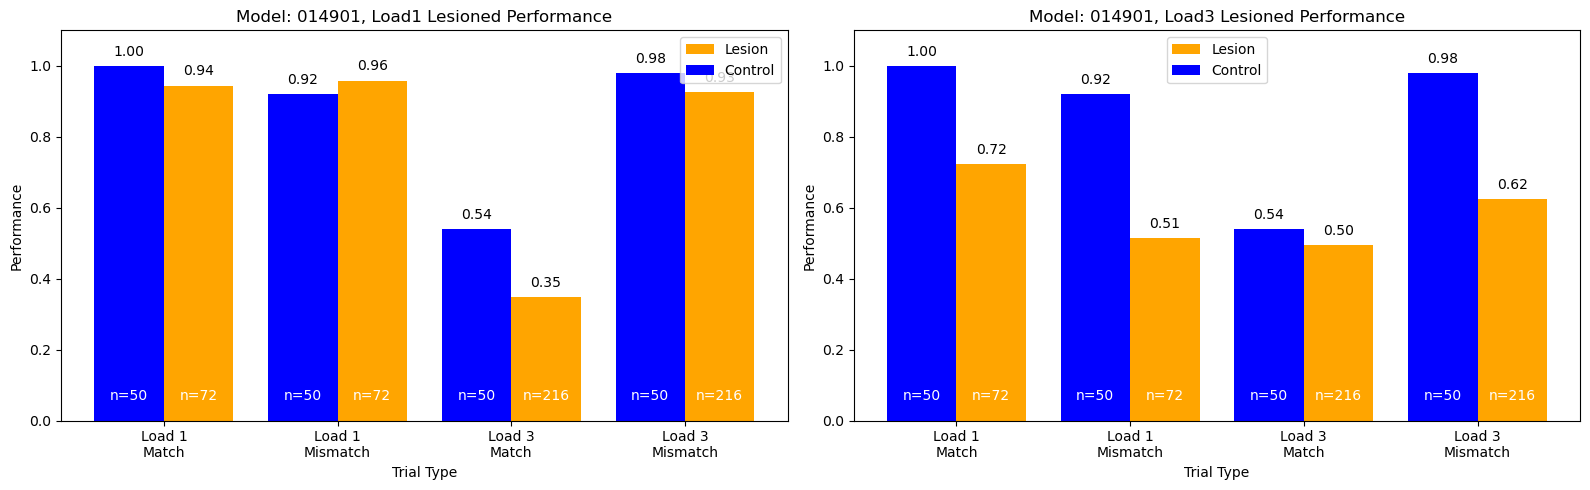

/tmp/ipykernel_835171/3650538290.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


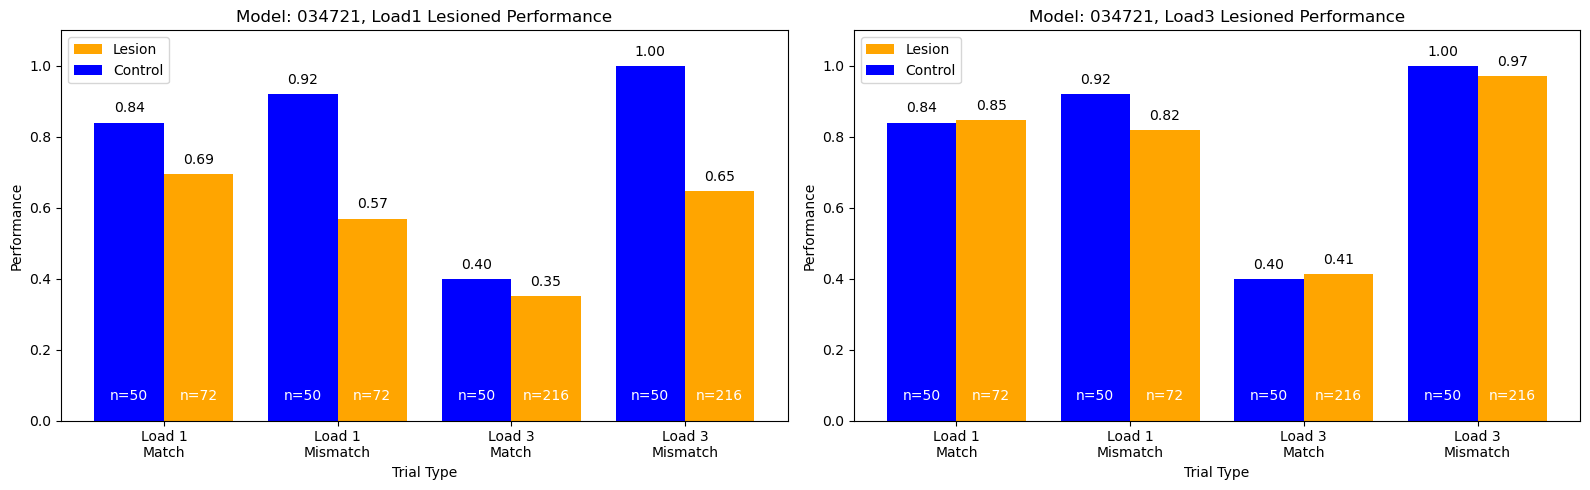

/tmp/ipykernel_835171/3650538290.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


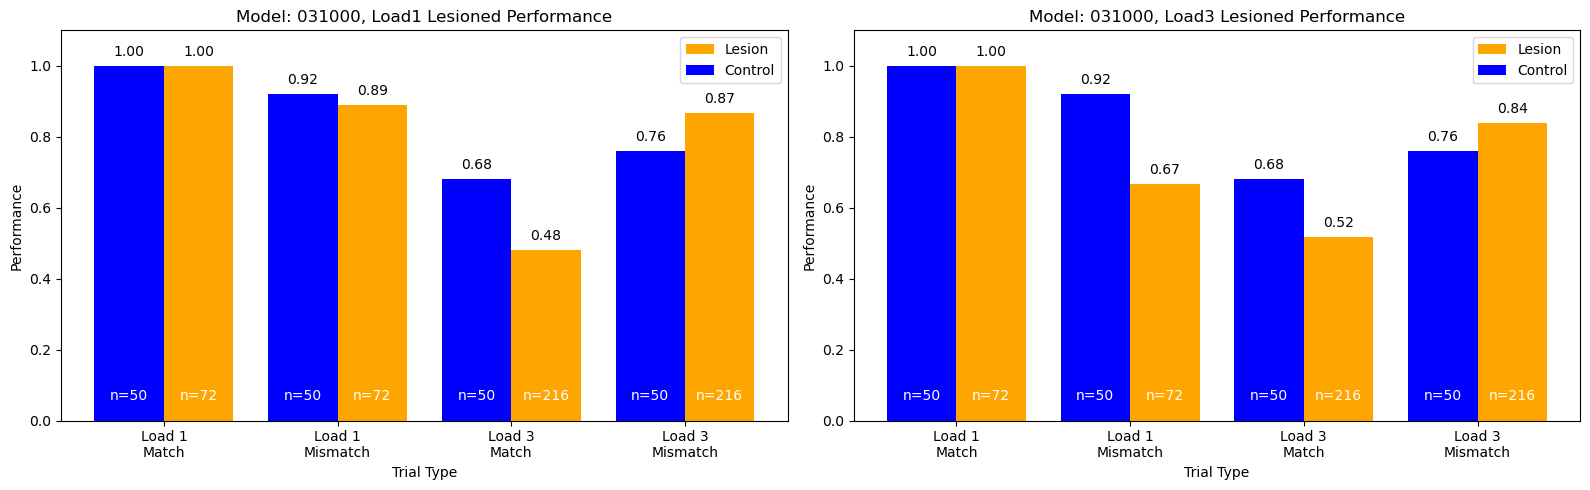

/tmp/ipykernel_835171/3650538290.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


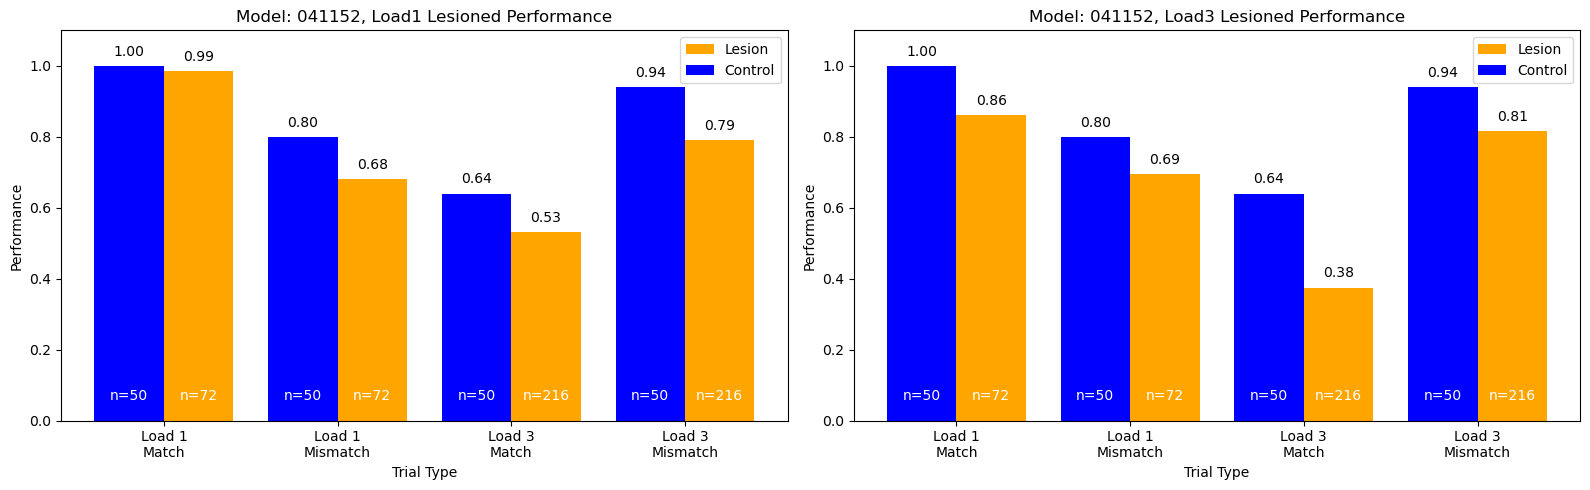

In [8]:
import matplotlib.gridspec as gridspec

condn_phrase = 'delay'
condn_num = 150

for model_name in model_names[:4]: # start with first 4 models for testing

    load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_stims",
                                all_models_dir=all_models_dir)
    load_selective = np.where(~np.isnan(load_tuning))[0]
    load_tuning = load_tuning[load_selective]

    trial_labels_ctrl, trial_perfs_ctrl, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels='balance_match',
        all_models_dir=all_models_dir
    )

    fig, axs = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
    for i, load_lesion in enumerate([1, 3]):
        other_labels = f'precomputed_lesion_maint_loadpref_{load_lesion:g}'.format(load_lesion)
        trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(
            model_name, condn_phrase, condn_num,
            other_labels=other_labels,
            all_models_dir=all_models_dir
        )
        
        # compare performance of lesion vs control, split by load & match/mismatch
        perfs_lesion = []
        perfs_ctrl = []
        n_lesion_trials = []
        n_ctrl_trials = []
        x_labels = []
        for j, load in enumerate([1, 3]):
            for k, match in enumerate([1, -1]):  # 1 = match, -1 = mismatch
                lesion_trial_idxs = np.where((trial_labels[:, 0] == load) & (trial_labels[:, 1] == match))[0]
                perfs_lesion.append(np.mean(trial_perfs[lesion_trial_idxs]))
                n_lesion_trials.append(len(lesion_trial_idxs))
                ctrl_trial_idxs = np.where((trial_labels_ctrl[:, 0] == load) & (trial_labels_ctrl[:, 1] == match))[0]
                perfs_ctrl.append(np.mean(trial_perfs_ctrl[ctrl_trial_idxs]))
                n_ctrl_trials.append(len(ctrl_trial_idxs))
                x_labels.append(f"Load {load}\n{'Match' if match == 1 else 'Mismatch'}")
        axs[i].bar(np.arange(len(perfs_lesion))+0.2, perfs_lesion, width=0.4, color='orange', alpha=1, label='Lesion')
        axs[i].bar(np.arange(len(perfs_ctrl))-0.2, perfs_ctrl, width=0.4, color='blue', alpha=1, label='Control')
        # show n inside bars
        for j, (perf_lesion, perf_ctrl) in enumerate(zip(perfs_lesion, perfs_ctrl)):
            axs[i].text(j+0.2, perf_lesion + 0.02, f"{perf_lesion:.2f}", ha='center', va='bottom', fontsize=10, color='black')
            axs[i].text(j-0.2, perf_ctrl + 0.02, f"{perf_ctrl:.2f}", ha='center', va='bottom', fontsize=10, color='black')
            axs[i].text(j+0.2, 0.05, f"n={n_lesion_trials[j]}", ha='center', va='bottom', fontsize=10, color='white')
            axs[i].text(j-0.2, 0.05, f"n={n_ctrl_trials[j]}", ha='center', va='bottom', fontsize=10, color='white')
        axs[i].set_ylabel("Performance")
        axs[i].set_xlabel("Trial Type")
        axs[i].set_xticks(np.arange(len(perfs_lesion)))
        axs[i].set_xticklabels(x_labels, rotation=0, ha='center')
        axs[i].set_ylim(0, 1.1)
        axs[i].legend()
        axs[i].set_title(f"Model: {model_name[-6:]}, Load{load_lesion} Lesioned Performance")
    
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_860131/1100944659.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


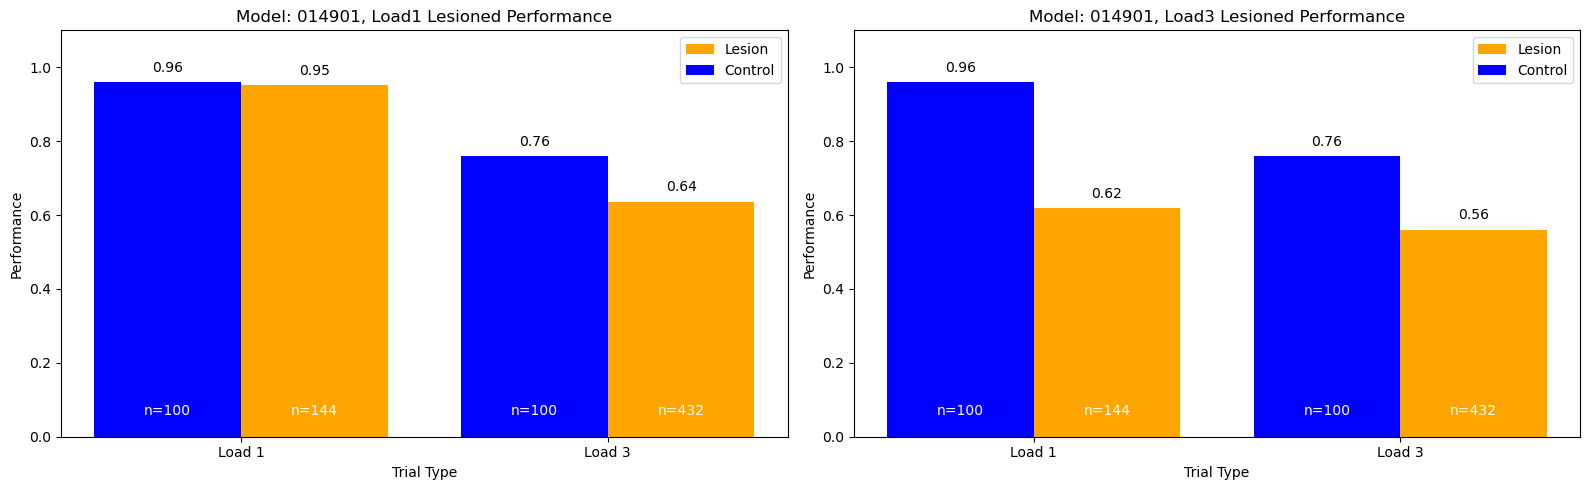

/tmp/ipykernel_860131/1100944659.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


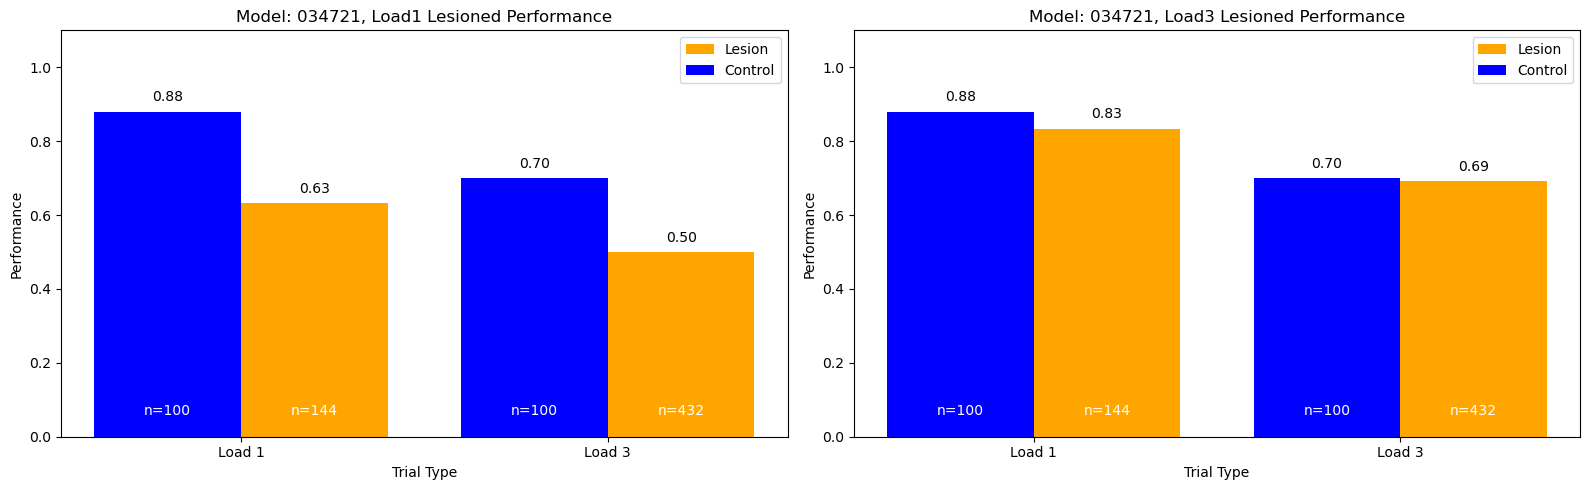

/tmp/ipykernel_860131/1100944659.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


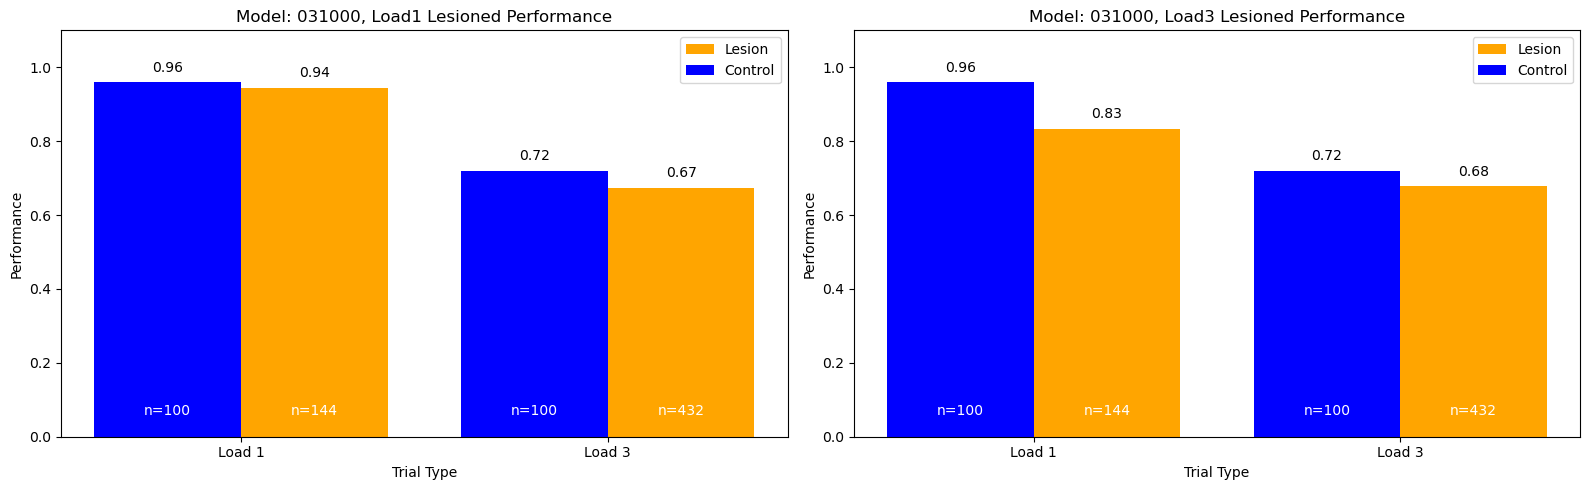

/tmp/ipykernel_860131/1100944659.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


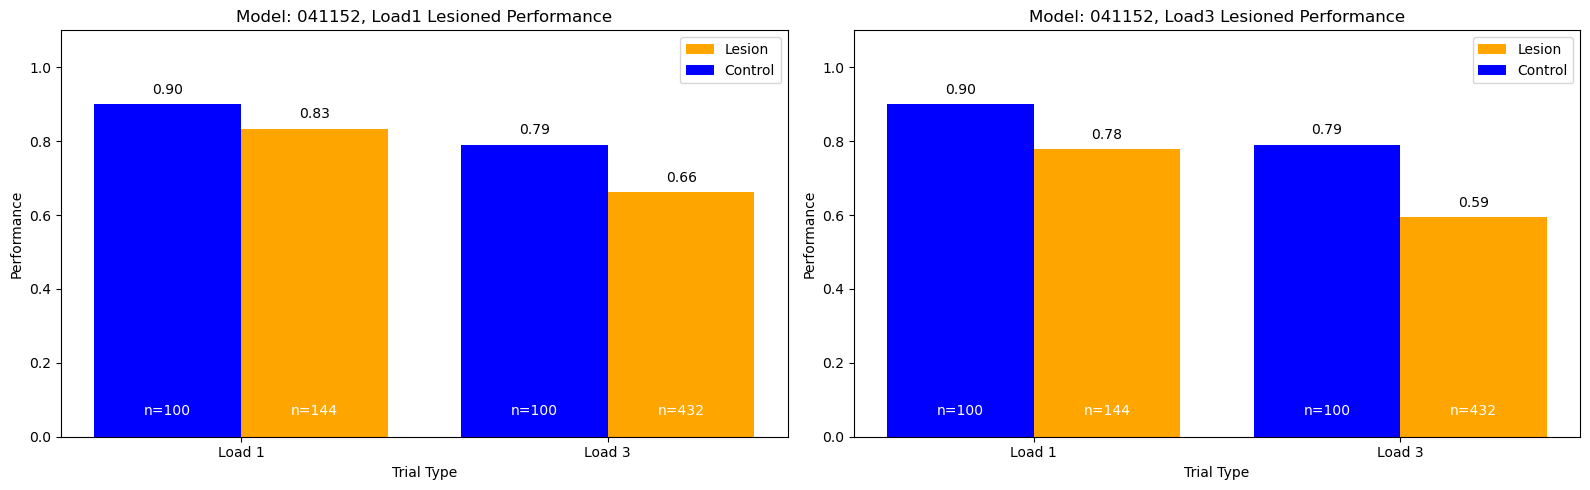

In [4]:
import matplotlib.gridspec as gridspec

condn_phrase = 'delay'
condn_num = 150

for model_name in model_names[:4]: # start with first 4 models for testing

    load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_stims",
                                all_models_dir=all_models_dir)
    load_selective = np.where(~np.isnan(load_tuning))[0]
    load_tuning = load_tuning[load_selective]

    trial_labels_ctrl, trial_perfs_ctrl, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels='balance_match',
        all_models_dir=all_models_dir
    )

    fig, axs = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
    for i, load_lesion in enumerate([1, 3]):
        other_labels = f'precomputed_lesion_maint_loadpref_{load_lesion:g}'.format(load_lesion)
        trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(
            model_name, condn_phrase, condn_num,
            other_labels=other_labels,
            all_models_dir=all_models_dir
        )
        
        # compare performance of lesion vs control, split by load & match/mismatch
        perfs_lesion = []
        perfs_ctrl = []
        n_lesion_trials = []
        n_ctrl_trials = []
        x_labels = []
        for j, load in enumerate([1, 3]):
            lesion_trial_idxs = np.where((trial_labels[:, 0] == load))[0]
            perfs_lesion.append(np.mean(trial_perfs[lesion_trial_idxs]))
            n_lesion_trials.append(len(lesion_trial_idxs))
            ctrl_trial_idxs = np.where((trial_labels_ctrl[:, 0] == load))[0]
            perfs_ctrl.append(np.mean(trial_perfs_ctrl[ctrl_trial_idxs]))
            n_ctrl_trials.append(len(ctrl_trial_idxs))
            x_labels.append(f"Load {load}")
        axs[i].bar(np.arange(len(perfs_lesion))+0.2, perfs_lesion, width=0.4, color='orange', alpha=1, label='Lesion')
        axs[i].bar(np.arange(len(perfs_ctrl))-0.2, perfs_ctrl, width=0.4, color='blue', alpha=1, label='Control')
        # show n inside bars
        for j, (perf_lesion, perf_ctrl) in enumerate(zip(perfs_lesion, perfs_ctrl)):
            axs[i].text(j+0.2, perf_lesion + 0.02, f"{perf_lesion:.2f}", ha='center', va='bottom', fontsize=10, color='black')
            axs[i].text(j-0.2, perf_ctrl + 0.02, f"{perf_ctrl:.2f}", ha='center', va='bottom', fontsize=10, color='black')
            axs[i].text(j+0.2, 0.05, f"n={n_lesion_trials[j]}", ha='center', va='bottom', fontsize=10, color='white')
            axs[i].text(j-0.2, 0.05, f"n={n_ctrl_trials[j]}", ha='center', va='bottom', fontsize=10, color='white')
        axs[i].set_ylabel("Performance")
        axs[i].set_xlabel("Trial Type")
        axs[i].set_xticks(np.arange(len(perfs_lesion)))
        axs[i].set_xticklabels(x_labels, rotation=0, ha='center')
        axs[i].set_ylim(0, 1.1)
        axs[i].legend()
        axs[i].set_title(f"Model: {model_name[-6:]}, Load{load_lesion} Lesioned Performance")
    
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_883308/1777940307.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


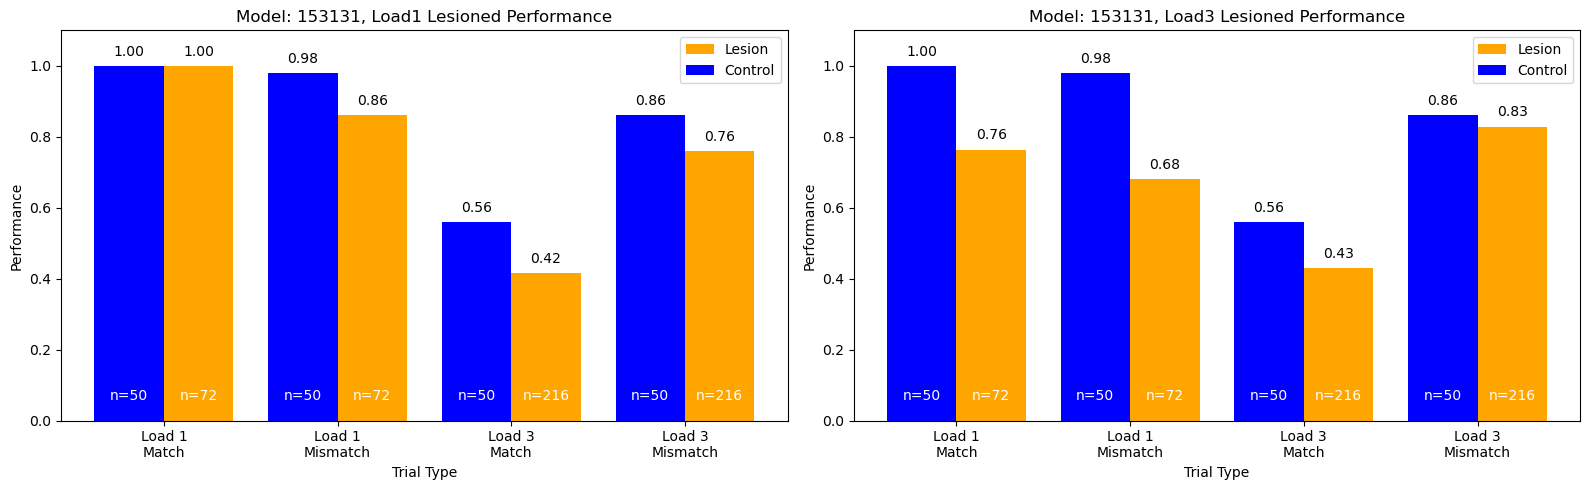

In [11]:
import matplotlib.gridspec as gridspec

condn_phrase = 'delay'
condn_num = 150

model_name = model_names[10] # pick one model to visualize

load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                            other_labels = "balance_stims",
                            all_models_dir=all_models_dir)
load_selective = np.where(~np.isnan(load_tuning))[0]
load_tuning = load_tuning[load_selective]

trial_labels_ctrl, trial_perfs_ctrl, _ = ld.load_bhv_rate_data(
    model_name, condn_phrase, condn_num,
    other_labels='balance_match',
    all_models_dir=all_models_dir
)

fig, axs = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
for i, load_lesion in enumerate([1, 3]):
    other_labels = f'precomputed_lesion_maint_loadpref_{load_lesion:g}'.format(load_lesion)
    trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels=other_labels,
        all_models_dir=all_models_dir
    )
    
    # compare performance of lesion vs control, split by load & match/mismatch
    perfs_lesion = []
    perfs_ctrl = []
    n_lesion_trials = []
    n_ctrl_trials = []
    x_labels = []
    for j, load in enumerate([1, 3]):
        for k, match in enumerate([1, -1]):  # 1 = match, -1 = mismatch
            lesion_trial_idxs = np.where((trial_labels[:, 0] == load) & (trial_labels[:, 1] == match))[0]
            perfs_lesion.append(np.mean(trial_perfs[lesion_trial_idxs]))
            n_lesion_trials.append(len(lesion_trial_idxs))
            ctrl_trial_idxs = np.where((trial_labels_ctrl[:, 0] == load) & (trial_labels_ctrl[:, 1] == match))[0]
            perfs_ctrl.append(np.mean(trial_perfs_ctrl[ctrl_trial_idxs]))
            n_ctrl_trials.append(len(ctrl_trial_idxs))
            x_labels.append(f"Load {load}\n{'Match' if match == 1 else 'Mismatch'}")
    axs[i].bar(np.arange(len(perfs_lesion))+0.2, perfs_lesion, width=0.4, color='orange', alpha=1, label='Lesion')
    axs[i].bar(np.arange(len(perfs_ctrl))-0.2, perfs_ctrl, width=0.4, color='blue', alpha=1, label='Control')
    # show n inside bars
    for j, (perf_lesion, perf_ctrl) in enumerate(zip(perfs_lesion, perfs_ctrl)):
        axs[i].text(j+0.2, perf_lesion + 0.02, f"{perf_lesion:.2f}", ha='center', va='bottom', fontsize=10, color='black')
        axs[i].text(j-0.2, perf_ctrl + 0.02, f"{perf_ctrl:.2f}", ha='center', va='bottom', fontsize=10, color='black')
        axs[i].text(j+0.2, 0.05, f"n={n_lesion_trials[j]}", ha='center', va='bottom', fontsize=10, color='white')
        axs[i].text(j-0.2, 0.05, f"n={n_ctrl_trials[j]}", ha='center', va='bottom', fontsize=10, color='white')
    axs[i].set_ylabel("Performance")
    axs[i].set_xlabel("Trial Type")
    axs[i].set_xticks(np.arange(len(perfs_lesion)))
    axs[i].set_xticklabels(x_labels, rotation=0, ha='center')
    axs[i].set_ylim(0, 1.1)
    axs[i].legend()
    axs[i].set_title(f"Model: {model_name[-6:]}, Load{load_lesion} Lesioned Performance")

plt.tight_layout()
plt.show()

/tmp/ipykernel_883308/2914171666.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


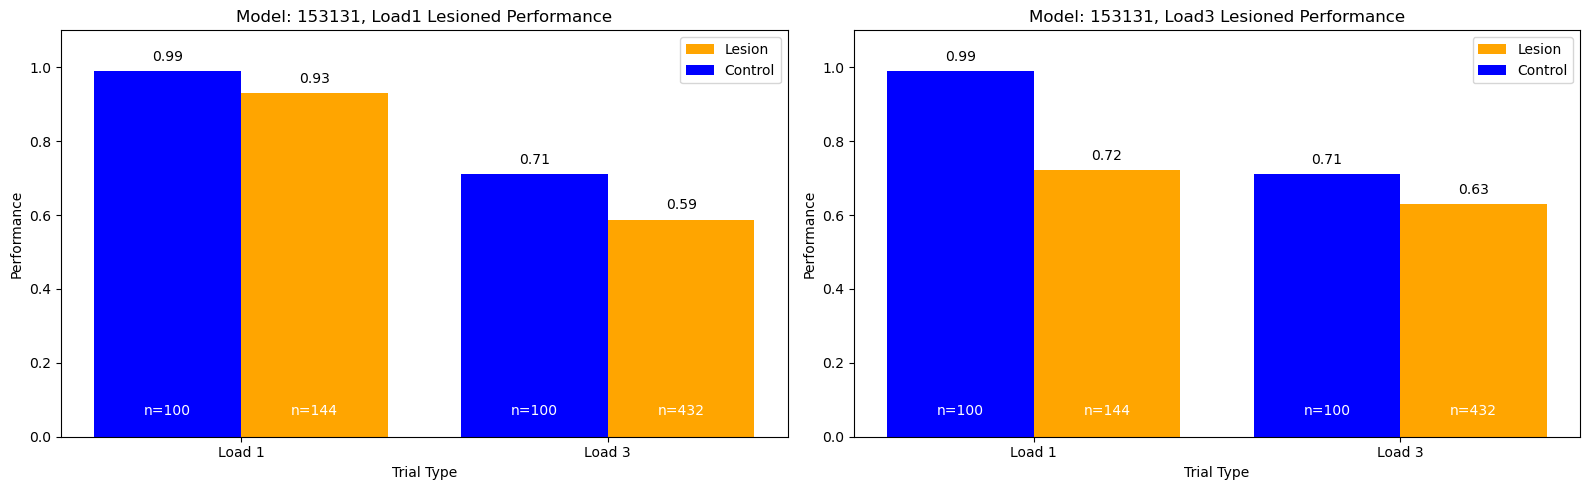

In [10]:
import matplotlib.gridspec as gridspec

condn_phrase = 'delay'
condn_num = 150

model_name = model_names[10]  # pick a specific model for demonstration

load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                            other_labels = "balance_stims",
                            all_models_dir=all_models_dir)
load_selective = np.where(~np.isnan(load_tuning))[0]
load_tuning = load_tuning[load_selective]

trial_labels_ctrl, trial_perfs_ctrl, _ = ld.load_bhv_rate_data(
    model_name, condn_phrase, condn_num,
    other_labels='balance_match',
    all_models_dir=all_models_dir
)

fig, axs = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
for i, load_lesion in enumerate([1, 3]):
    other_labels = f'precomputed_lesion_maint_loadpref_{load_lesion:g}'.format(load_lesion)
    trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels=other_labels,
        all_models_dir=all_models_dir
    )
    
    # compare performance of lesion vs control, split by load & match/mismatch
    perfs_lesion = []
    perfs_ctrl = []
    n_lesion_trials = []
    n_ctrl_trials = []
    x_labels = []
    for j, load in enumerate([1, 3]):
        lesion_trial_idxs = np.where((trial_labels[:, 0] == load))[0]
        perfs_lesion.append(np.mean(trial_perfs[lesion_trial_idxs]))
        n_lesion_trials.append(len(lesion_trial_idxs))
        ctrl_trial_idxs = np.where((trial_labels_ctrl[:, 0] == load))[0]
        perfs_ctrl.append(np.mean(trial_perfs_ctrl[ctrl_trial_idxs]))
        n_ctrl_trials.append(len(ctrl_trial_idxs))
        x_labels.append(f"Load {load}")
    axs[i].bar(np.arange(len(perfs_lesion))+0.2, perfs_lesion, width=0.4, color='orange', alpha=1, label='Lesion')
    axs[i].bar(np.arange(len(perfs_ctrl))-0.2, perfs_ctrl, width=0.4, color='blue', alpha=1, label='Control')
    # show n inside bars
    for j, (perf_lesion, perf_ctrl) in enumerate(zip(perfs_lesion, perfs_ctrl)):
        axs[i].text(j+0.2, perf_lesion + 0.02, f"{perf_lesion:.2f}", ha='center', va='bottom', fontsize=10, color='black')
        axs[i].text(j-0.2, perf_ctrl + 0.02, f"{perf_ctrl:.2f}", ha='center', va='bottom', fontsize=10, color='black')
        axs[i].text(j+0.2, 0.05, f"n={n_lesion_trials[j]}", ha='center', va='bottom', fontsize=10, color='white')
        axs[i].text(j-0.2, 0.05, f"n={n_ctrl_trials[j]}", ha='center', va='bottom', fontsize=10, color='white')
    axs[i].set_ylabel("Performance")
    axs[i].set_xlabel("Trial Type")
    axs[i].set_xticks(np.arange(len(perfs_lesion)))
    axs[i].set_xticklabels(x_labels, rotation=0, ha='center')
    axs[i].set_ylim(0, 1.1)
    axs[i].legend()
    axs[i].set_title(f"Model: {model_name[-6:]}, Load{load_lesion} Lesioned Performance")

plt.tight_layout()
plt.show()

In [13]:
# plot summary paired boxplots with all models together

load1_perfs = np.zeros((len(model_names), 3))  # columns: [control, lesion-load1, lesion-load3]
load3_perfs = np.zeros((len(model_names), 3))  # columns: [control, lesion-load1, lesion-load3]

for i, model_name in enumerate(model_names):
    trial_labels_ctrl, trial_perfs_ctrl, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels='balance_match',
        all_models_dir=all_models_dir
    )
    
    # Control performance
    ctrl_trial_idxs_load1 = np.where((trial_labels_ctrl[:, 0] == 1))[0]
    load1_perfs[i, 0] = np.mean(trial_perfs_ctrl[ctrl_trial_idxs_load1])
    ctrl_trial_idxs_load3 = np.where((trial_labels_ctrl[:, 0] == 3))[0]
    load3_perfs[i, 0] = np.mean(trial_perfs_ctrl[ctrl_trial_idxs_load3])
    
    # Lesion load1 performance
    other_labels_lesion_load1 = f'precomputed_lesion_maint_loadpref_1'
    trial_labels_lesion_load1, trial_perfs_lesion_load1, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels=other_labels_lesion_load1,
        all_models_dir=all_models_dir
    )
    lesion_trial_idxs_load1 = np.where((trial_labels_lesion_load1[:, 0] == 1))[0]
    load1_perfs[i, 1] = np.mean(trial_perfs_lesion_load1[lesion_trial_idxs_load1])
    lesion_trial_idxs_load3 = np.where((trial_labels_lesion_load1[:, 0] == 3))[0]
    load3_perfs[i, 1] = np.mean(trial_perfs_lesion_load1[lesion_trial_idxs_load3])
    
    # Lesion load3 performance
    other_labels_lesion_load3 = f'precomputed_lesion_maint_loadpref_3'
    trial_labels_lesion_load3, trial_perfs_lesion_load3, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels=other_labels_lesion_load3,
        all_models_dir=all_models_dir
    )
    lesion_trial_idxs_load1 = np.where((trial_labels_lesion_load3[:, 0] == 1))[0]
    load1_perfs[i, 2] = np.mean(trial_perfs_lesion_load3[lesion_trial_idxs_load1])
    lesion_trial_idxs_load3 = np.where((trial_labels_lesion_load3[:, 0] == 3))[0]
    load3_perfs[i, 2] = np.mean(trial_perfs_lesion_load3[lesion_trial_idxs_load3])
    

In [18]:
x

array([0, 1, 2])

/tmp/ipykernel_883308/119539446.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(load1_perfs, positions=x-0.2, widths=0.3, patch_artist=True, boxprops=dict(facecolor='yellow', color='black'), medianprops=dict(color='black'), labels=x_labels)
/tmp/ipykernel_883308/119539446.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(load3_perfs, positions=x+0.2, widths=0.3, patch_artist=True, boxprops=dict(facecolor='magenta', color='black'), medianprops=dict(color='black'), labels=x_labels)


Wilcoxon test for Load 1: Control vs Lesion Load 1, p-value = 0.0039
Wilcoxon test for Load 1: Control vs Lesion Load 3, p-value = 0.0010
Wilcoxon test for Load 3: Lesion Load 1 vs Lesion Load 3, p-value = 0.5195
Wilcoxon test for Load 3: Control vs Lesion Load 1, p-value = 0.0020
Wilcoxon test for Load 3: Control vs Lesion Load 3, p-value = 0.0010
Wilcoxon test for Load 1: Lesion Load 1 vs Lesion Load 3, p-value = 0.1055


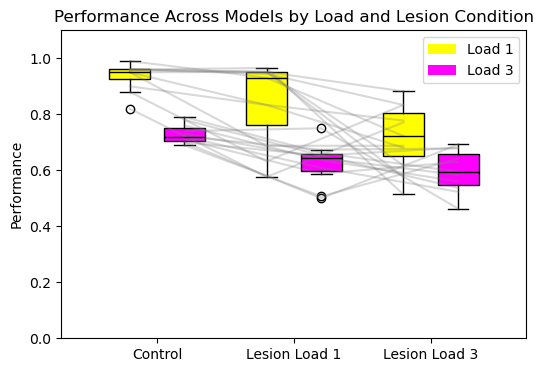

In [24]:
# plot summary paired boxplots with all models together

x_labels = ['Control', 'Lesion Load 1', 'Lesion Load 3']
x = np.arange(len(x_labels))

plt.figure(figsize=(6,4))
plt.boxplot(load1_perfs, positions=x-0.2, widths=0.3, patch_artist=True, boxprops=dict(facecolor='yellow', color='black'), medianprops=dict(color='black'), labels=x_labels)
plt.boxplot(load3_perfs, positions=x+0.2, widths=0.3, patch_artist=True, boxprops=dict(facecolor='magenta', color='black'), medianprops=dict(color='black'), labels=x_labels)

from scipy.stats import wilcoxon
_, p = wilcoxon(load1_perfs[:, 0], load1_perfs[:, 1])
print(f"Wilcoxon test for Load 1: Control vs Lesion Load 1, p-value = {p:.4f}")
# plt.text(0.8, 0.2, f"p={p:.3f}", ha='center', va='bottom', fontsize=10, color='black', transform=plt.gca().transAxes)

_, p = wilcoxon(load1_perfs[:, 0], load1_perfs[:, 2])
print(f"Wilcoxon test for Load 1: Control vs Lesion Load 3, p-value = {p:.4f}")
# plt.text(1.8, 0.2, f"p={p:.3f}", ha='center', va='bottom', fontsize=10, color='black', transform=plt.gca().transAxes)

_, p = wilcoxon(load3_perfs[:, 1], load3_perfs[:, 2])
print(f"Wilcoxon test for Load 3: Lesion Load 1 vs Lesion Load 3, p-value = {p:.4f}")

_, p = wilcoxon(load3_perfs[:, 0], load3_perfs[:, 1])
print(f"Wilcoxon test for Load 3: Control vs Lesion Load 1, p-value = {p:.4f}")
# plt.text(1.2, 0.2, f"p={p:.3f}", ha='center', va='bottom', fontsize=10, color='black', transform=plt.gca().transAxes)

_, p = wilcoxon(load3_perfs[:, 0], load3_perfs[:, 2])
print(f"Wilcoxon test for Load 3: Control vs Lesion Load 3, p-value = {p:.4f}")
# plt.text(2.2, 0.2, f"p={p:.3f}", ha='center', va='bottom', fontsize=10, color='black', transform=plt.gca().transAxes)

_, p = wilcoxon(load1_perfs[:, 1], load1_perfs[:, 2])
print(f"Wilcoxon test for Load 1: Lesion Load 1 vs Lesion Load 3, p-value = {p:.4f}")

# draw gray lines
for i in range(len(model_names)):
    plt.plot(x-0.2, load1_perfs[i, :], color='gray', alpha=0.3)
    plt.plot(x+0.2, load3_perfs[i, :], color='gray', alpha=0.3)


plt.xticks(x, x_labels)
plt.ylabel('Performance')
plt.title('Performance Across Models by Load and Lesion Condition')
plt.legend([plt.Rectangle((0,0),1,1,facecolor='yellow'), plt.Rectangle((0,0),1,1,facecolor='magenta')], 
           ['Load 1', 'Load 3'], loc='upper right')
plt.ylim(0, 1.1)
plt.show()

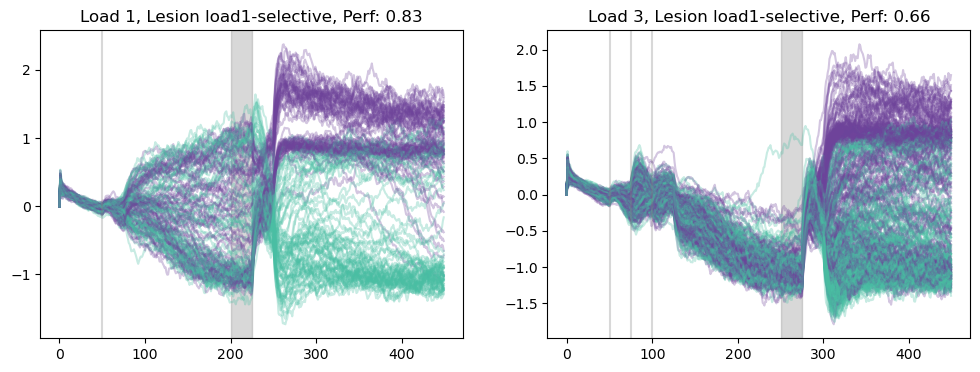

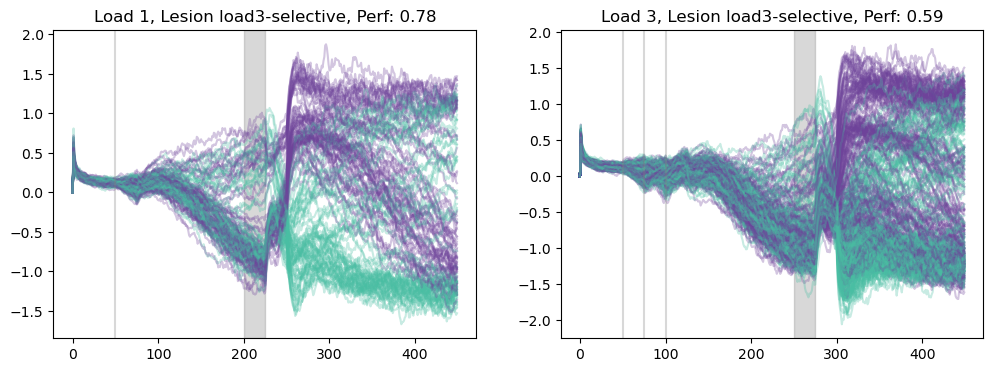

In [9]:
# check out the outputs to make sure it's ok
condn_phrase='delay'
condn_num=150

model_name = model_names[3]
    
for load_lesion in [1,3]: # 0, 1, 2, 3

    other_labels=f'precomputed_lesion_maint_loadpref_{load_lesion:g}'.format(load_lesion)
    trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels=other_labels,
                                                        all_models_dir=all_models_dir)
    
    # plot outputs
    colors = ["#49BEA3", "#6E439A"]
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    for i, load in enumerate([1, 3]):
        this_load_idx = np.where(trial_labels[:, 0] == load)[0]
        for n in this_load_idx:
            axs[i].plot(
                trial_outputs[n],
                color=colors[int(trial_labels[n,1] == 1)],
                alpha=0.3,
            )

        perf = np.mean(np.array(trial_perfs)[this_load_idx])
        axs[i].set_title(f"Load {load}, Lesion load{load_lesion}-selective, Perf: {perf:.2f}")
        for n in range(load):
            stim_on = settings["stim_on"] + n * settings["stim_dur"]
            axs[i].axvline(stim_on, color="gray", alpha=0.3)
        axs[i].axvspan(
            stim_on + settings["delay"],
            stim_on + settings["delay"] + settings["stim_dur"],
            color="gray",
            alpha=0.3,
        )
    plt.show()

In [32]:
settings

{'T': 450,
 'stim_on': 50,
 'stim_dur': 25,
 'delay': 150,
 'DeltaT': 1,
 'taus': 20,
 'fs': 200,
 'task': 'sternberg',
 'load': 1}

In [15]:
# try using a shorter cut-off for the evaluation period

def recalc_trialperfs(trial_labels, trial_outputs, trial_perfs, settings, eval_dur=50):
    """
    Recalculate trial_perfs from trial_outputs using a threshold.
    """
    threshold=0.7

    trial_perfs_recalc = np.zeros_like(trial_perfs)
    for i, (labels, outputs) in enumerate(zip(trial_labels, trial_outputs)):
        load = int(labels[0])
        label = int(labels[1])
        resp_onset = int(settings["stim_on"] + load * settings["stim_dur"] + 
                         settings["delay"] + settings["stim_dur"] + 10)
        resp_offset = int(resp_onset + eval_dur)
        if label == 1:
            trial_perfs_recalc[i] = int(np.max(outputs[resp_onset:resp_offset]) > threshold)
        else:
            trial_perfs_recalc[i] = int(np.min(outputs[resp_onset:resp_offset]) < -threshold)

    print(f"Original trial_perfs: {np.mean(trial_perfs):.3f}")
    print(f"Recalculated trial_perfs: {np.mean(trial_perfs_recalc):.3f}")

    return trial_perfs_recalc

Original trial_perfs: 0.705
Recalculated trial_perfs: 0.658


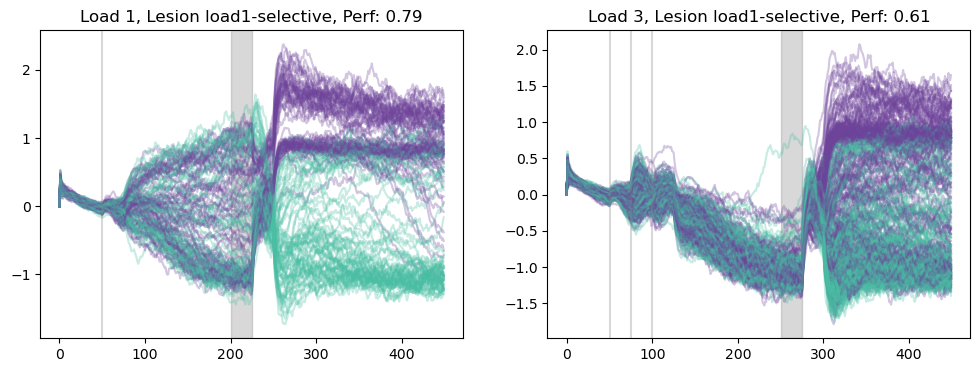

Original trial_perfs: 0.641
Recalculated trial_perfs: 0.632


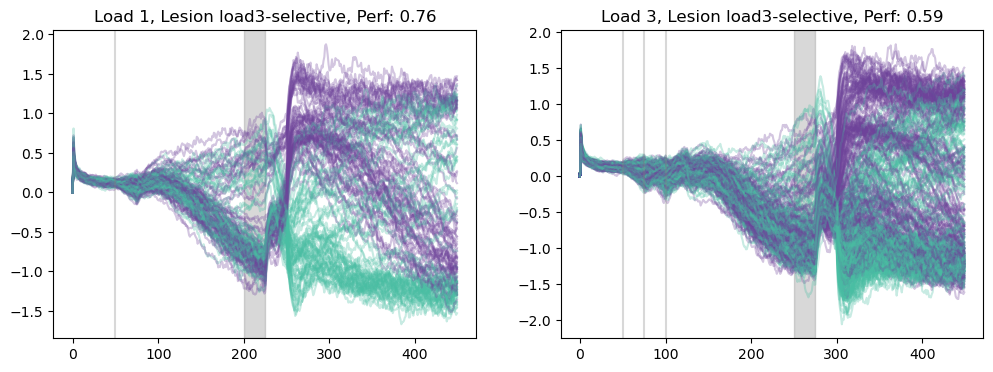

In [16]:
# check out the outputs to make sure it's ok
condn_phrase='delay'
condn_num=150

model_name = model_names[3]
    
for load_lesion in [1,3]: # 0, 1, 2, 3

    other_labels=f'precomputed_lesion_maint_loadpref_{load_lesion:g}'.format(load_lesion)
    trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels=other_labels,
                                                        all_models_dir=all_models_dir)
    
    trial_perfs_recalc = recalc_trialperfs(trial_labels, trial_outputs, trial_perfs, settings, eval_dur=50)
    
    # plot outputs
    colors = ["#49BEA3", "#6E439A"]
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    for i, load in enumerate([1, 3]):
        this_load_idx = np.where(trial_labels[:, 0] == load)[0]
        for n in this_load_idx:
            axs[i].plot(
                trial_outputs[n],
                color=colors[int(trial_labels[n,1] == 1)],
                alpha=0.3,
            )

        perf = np.mean(np.array(trial_perfs_recalc)[this_load_idx])
        axs[i].set_title(f"Load {load}, Lesion load{load_lesion}-selective, Perf: {perf:.2f}")
        for n in range(load):
            stim_on = settings["stim_on"] + n * settings["stim_dur"]
            axs[i].axvline(stim_on, color="gray", alpha=0.3)
        axs[i].axvspan(
            stim_on + settings["delay"],
            stim_on + settings["delay"] + settings["stim_dur"],
            color="gray",
            alpha=0.3,
        )
    plt.show()

Original trial_perfs: 0.705
Recalculated trial_perfs: 0.658


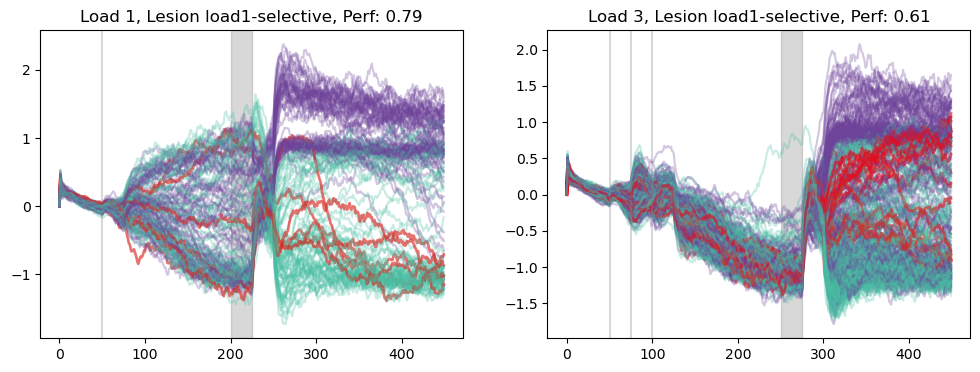

Original trial_perfs: 0.641
Recalculated trial_perfs: 0.632


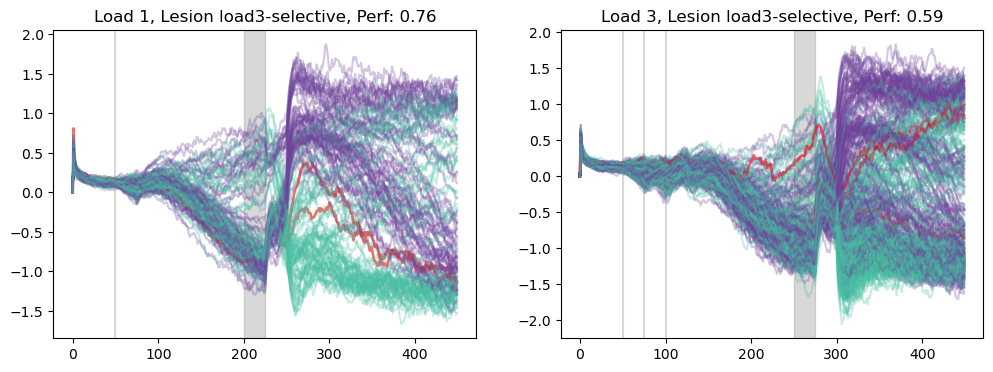

In [17]:
# check out the outputs to make sure it's ok
condn_phrase='delay'
condn_num=150

model_name = model_names[3]
    
for load_lesion in [1,3]: # 0, 1, 2, 3

    other_labels=f'precomputed_lesion_maint_loadpref_{load_lesion:g}'.format(load_lesion)
    trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels=other_labels,
                                                        all_models_dir=all_models_dir)
    
    trial_perfs_recalc = recalc_trialperfs(trial_labels, trial_outputs, trial_perfs, settings, eval_dur=50)
    
    changed_idxs = np.where(trial_perfs != trial_perfs_recalc)[0]
    
    # plot outputs
    colors = ["#49BEA3", "#6E439A"]
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    for i, load in enumerate([1, 3]):
        this_load_idx = np.where(trial_labels[:, 0] == load)[0]
        for n in this_load_idx:
            axs[i].plot(
                trial_outputs[n],
                color=colors[int(trial_labels[n,1] == 1)],
                alpha=0.3,
            )
            if n in changed_idxs:
                axs[i].plot(
                    trial_outputs[n],
                    color='red',
                    alpha=0.5,
                    linewidth=2,
                )

        perf = np.mean(np.array(trial_perfs_recalc)[this_load_idx])
        axs[i].set_title(f"Load {load}, Lesion load{load_lesion}-selective, Perf: {perf:.2f}")
        for n in range(load):
            stim_on = settings["stim_on"] + n * settings["stim_dur"]
            axs[i].axvline(stim_on, color="gray", alpha=0.3)
        axs[i].axvspan(
            stim_on + settings["delay"],
            stim_on + settings["delay"] + settings["stim_dur"],
            color="gray",
            alpha=0.3,
        )
    plt.show()

## lesion inh only by 50%

In [6]:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3'

model_paths = ['Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_041152.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_180002.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_233744.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_023239.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_043128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063647.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_153131.mat']

model_names = [os.path.basename(m)[:-4] for m in model_paths]

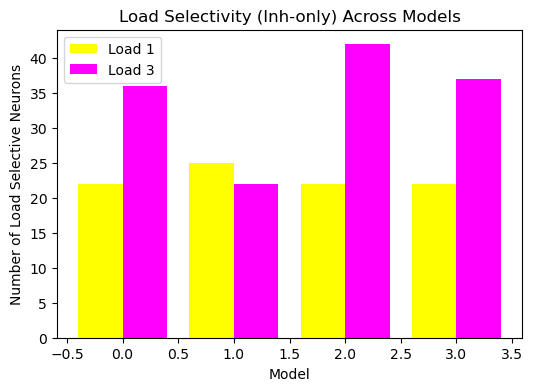

In [7]:
condn_phrase = 'delay'
condn_num=150

n_load1 = []
n_load3 = []
for model_name in model_names[:4]: # start with first 4 models for testing
    
    model_dir = os.path.join(all_models_dir, model_name)
    load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_stims",
                                all_models_dir=all_models_dir)
    load_selective = np.where(~np.isnan(load_tuning))[0]
    load_tuning = load_tuning[load_selective]
    exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

    for load in [1,3]: # loads we're testing
        neuron_idxs = load_selective[load_tuning == load] # neuron indices for this specific stimulus
        neuron_idxs = np.intersect1d(neuron_idxs, inh_ind) # only include inhibitory neurons
        if load == 1:
            n_load1.append(len(neuron_idxs))
        elif load == 3:
            n_load3.append(len(neuron_idxs))
            
plt.figure(figsize=(6,4))
plt.bar(np.arange(len(n_load1))-0.2, n_load1, width=0.4, label='Load 1', align='center', color='yellow')
plt.bar(np.arange(len(n_load3))+0.2, n_load3, width=0.4, label='Load 3', align='center', color='magenta')
plt.xlabel('Model')
plt.ylabel('Number of Load Selective Neurons')
plt.title('Load Selectivity (Inh-only) Across Models')
plt.legend()
plt.show()

In [8]:


# should generate same stimset no matter what we're lesioning here
stims = [0, 1, 2, 3]
trial_type_load3 = generate_sternberg_trialtypes_load3(stims, shuffle=False, n_repeats=3, seed=42)
trial_type_load1 = generate_sternberg_trialtypes_load1(stims, shuffle=False, n_repeats=6, seed=42)
trial_type_all = np.vstack([trial_type_load3, trial_type_load1])
u_all = generate_u_from_trialtypes(trial_type_all, settings)

for model_name in model_names[:4]: # start with first 4 models for testing
    
    model_dir = os.path.join(all_models_dir, model_name)
    load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_stims",
                                all_models_dir=all_models_dir)
    load_selective = np.where(~np.isnan(load_tuning))[0]
    load_tuning = load_tuning[load_selective]
    exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

    for load in [1,3]: # loads we're testing
        neuron_idxs = load_selective[load_tuning == load] # neuron indices for this specific stimulus
        neuron_idxs = np.intersect1d(neuron_idxs, inh_ind) # only include inhibitory neurons
        
        grdm.generate_data(
            model_dir="/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3",
            pattern="*N_1000*.mat",
            n_repetitions=3,          # used by balance_stims (unused)
            eval_amp_threshold=0.7,
            workers=1,
            backend="torch",
            device="cuda",
            overwrite=False,
            mode="precomputed",     # or "balance_match" / "balance_stims"
            n_trials=50,              # used by balance_match (unused)
            loads=[1, 3],             # used by balance_match (unused)
            lesion="custom",
            lesion_inds=[(None, neuron_idxs)], # (postsyn, presyn)
            lesion_scale=0.5,
            lesion_tag=f"maint_inh_loadpref_{load:g}",
            include_models=[model_name],
            u_all = u_all,
            trial_type_all = trial_type_all
        )

Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/ren

/tmp/ipykernel_859242/330122668.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


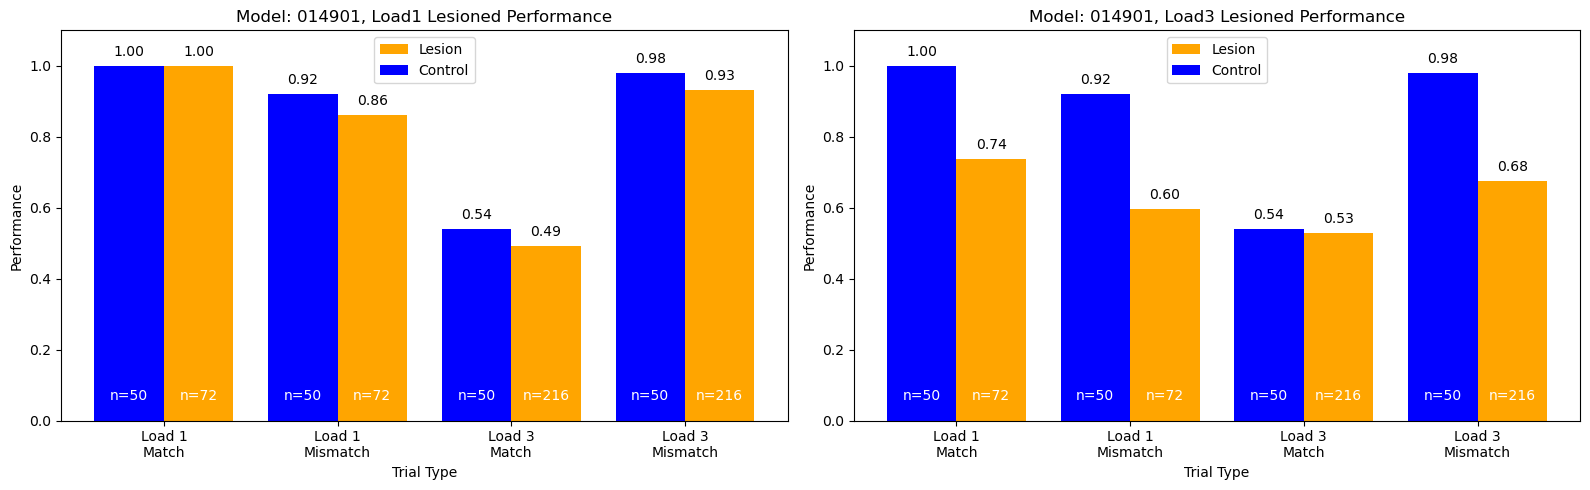

/tmp/ipykernel_859242/330122668.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


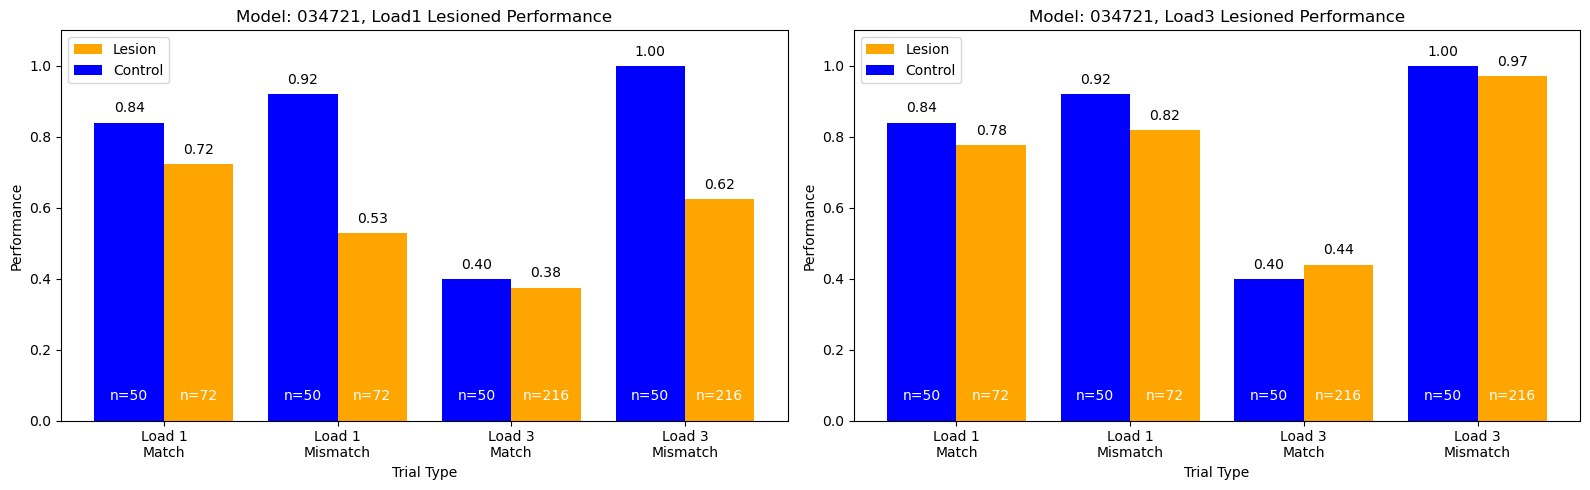

/tmp/ipykernel_859242/330122668.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


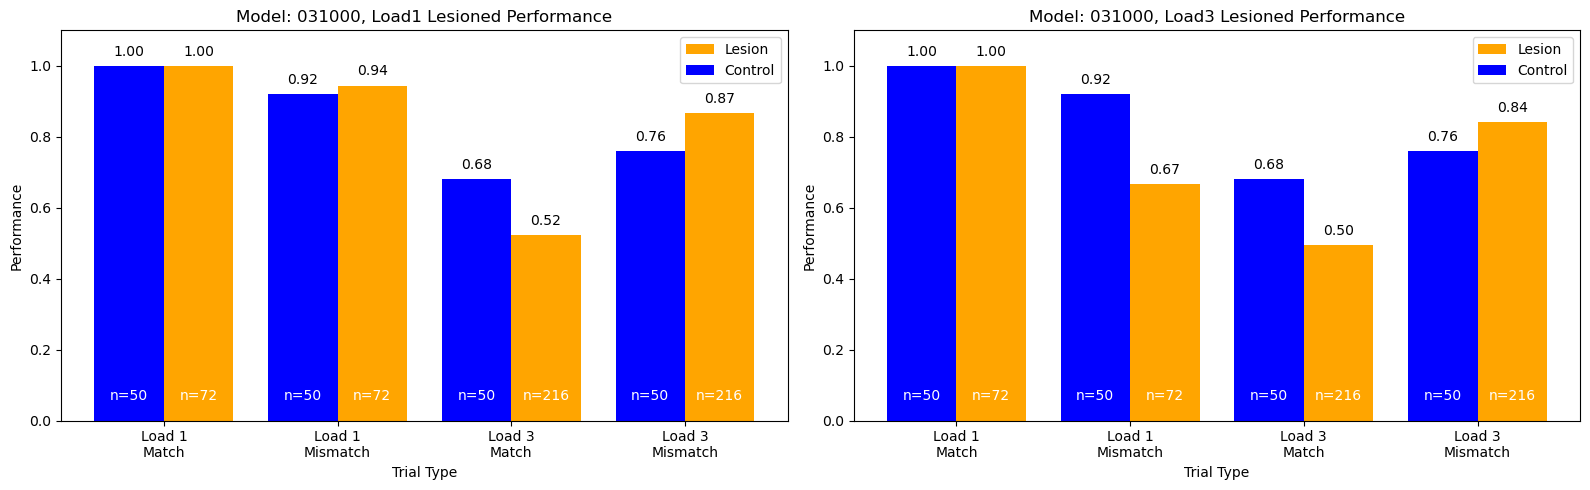

/tmp/ipykernel_859242/330122668.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


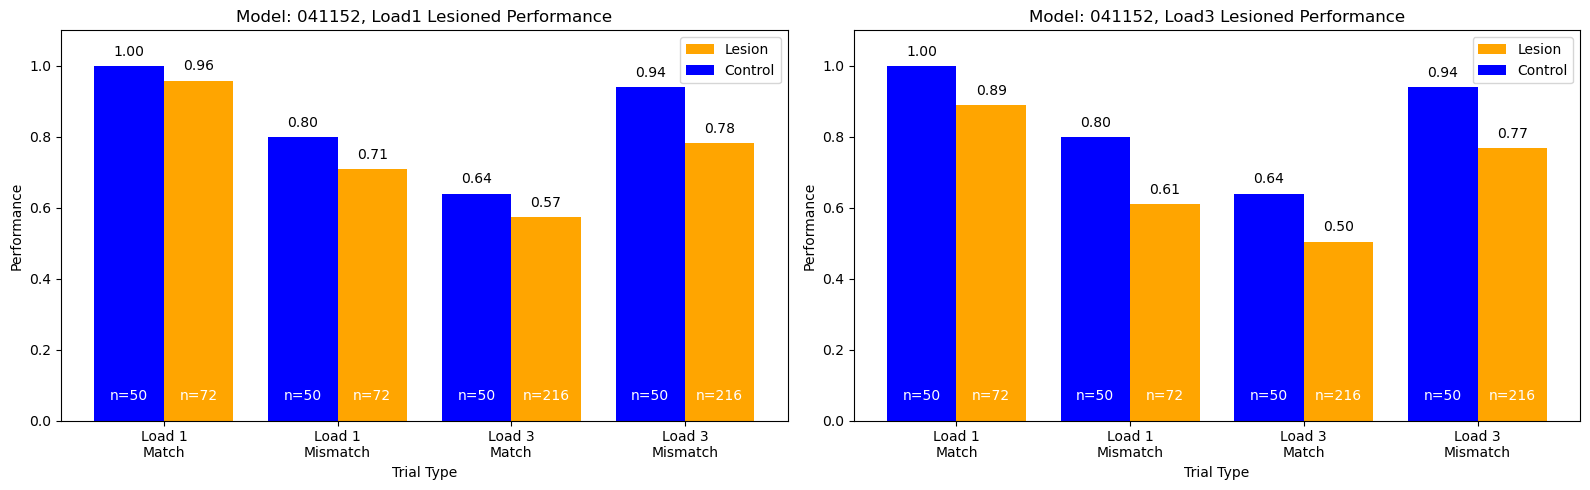

In [9]:
import matplotlib.gridspec as gridspec

condn_phrase = 'delay'
condn_num = 150

for model_name in model_names[:4]: # start with first 4 models for testing

    load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_stims",
                                all_models_dir=all_models_dir)
    load_selective = np.where(~np.isnan(load_tuning))[0]
    load_tuning = load_tuning[load_selective]

    trial_labels_ctrl, trial_perfs_ctrl, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels='balance_match',
        all_models_dir=all_models_dir
    )

    fig, axs = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
    for i, load_lesion in enumerate([1, 3]):
        other_labels = f'precomputed_lesion_maint_inh_loadpref_{load_lesion:g}'.format(load_lesion)
        trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(
            model_name, condn_phrase, condn_num,
            other_labels=other_labels,
            all_models_dir=all_models_dir
        )
        
        # compare performance of lesion vs control, split by load & match/mismatch
        perfs_lesion = []
        perfs_ctrl = []
        n_lesion_trials = []
        n_ctrl_trials = []
        x_labels = []
        for j, load in enumerate([1, 3]):
            for k, match in enumerate([1, -1]):  # 1 = match, -1 = mismatch
                lesion_trial_idxs = np.where((trial_labels[:, 0] == load) & (trial_labels[:, 1] == match))[0]
                perfs_lesion.append(np.mean(trial_perfs[lesion_trial_idxs]))
                n_lesion_trials.append(len(lesion_trial_idxs))
                ctrl_trial_idxs = np.where((trial_labels_ctrl[:, 0] == load) & (trial_labels_ctrl[:, 1] == match))[0]
                perfs_ctrl.append(np.mean(trial_perfs_ctrl[ctrl_trial_idxs]))
                n_ctrl_trials.append(len(ctrl_trial_idxs))
                x_labels.append(f"Load {load}\n{'Match' if match == 1 else 'Mismatch'}")
        axs[i].bar(np.arange(len(perfs_lesion))+0.2, perfs_lesion, width=0.4, color='orange', alpha=1, label='Lesion')
        axs[i].bar(np.arange(len(perfs_ctrl))-0.2, perfs_ctrl, width=0.4, color='blue', alpha=1, label='Control')
        # show n inside bars
        for j, (perf_lesion, perf_ctrl) in enumerate(zip(perfs_lesion, perfs_ctrl)):
            axs[i].text(j+0.2, perf_lesion + 0.02, f"{perf_lesion:.2f}", ha='center', va='bottom', fontsize=10, color='black')
            axs[i].text(j-0.2, perf_ctrl + 0.02, f"{perf_ctrl:.2f}", ha='center', va='bottom', fontsize=10, color='black')
            axs[i].text(j+0.2, 0.05, f"n={n_lesion_trials[j]}", ha='center', va='bottom', fontsize=10, color='white')
            axs[i].text(j-0.2, 0.05, f"n={n_ctrl_trials[j]}", ha='center', va='bottom', fontsize=10, color='white')
        axs[i].set_ylabel("Performance")
        axs[i].set_xlabel("Trial Type")
        axs[i].set_xticks(np.arange(len(perfs_lesion)))
        axs[i].set_xticklabels(x_labels, rotation=0, ha='center')
        axs[i].set_ylim(0, 1.1)
        axs[i].legend()
        axs[i].set_title(f"Model: {model_name[-6:]}, Load{load_lesion} Lesioned Performance")
    
    plt.tight_layout()
    plt.show()

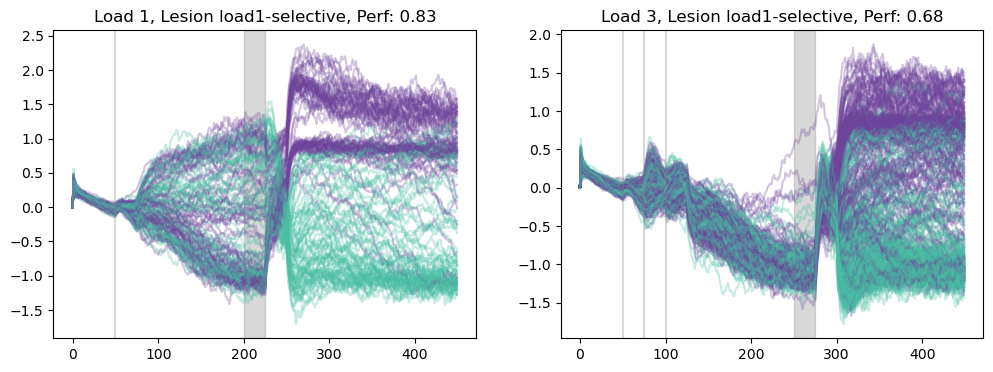

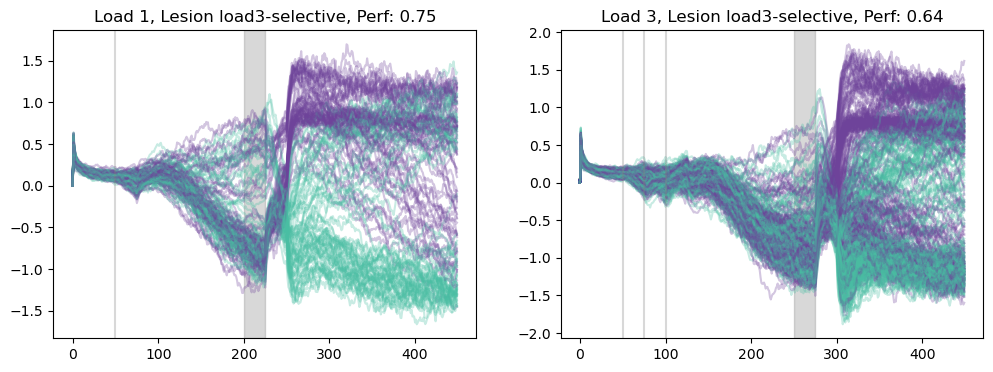

In [10]:
# check out the outputs to make sure it's ok
condn_phrase='delay'
condn_num=150

model_name = model_names[3]
    
for load_lesion in [1,3]: # 0, 1, 2, 3

    other_labels=f'precomputed_lesion_maint_inh_loadpref_{load_lesion:g}'.format(load_lesion)
    trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels=other_labels,
                                                        all_models_dir=all_models_dir)
    
    # plot outputs
    colors = ["#49BEA3", "#6E439A"]
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    for i, load in enumerate([1, 3]):
        this_load_idx = np.where(trial_labels[:, 0] == load)[0]
        for n in this_load_idx:
            axs[i].plot(
                trial_outputs[n],
                color=colors[int(trial_labels[n,1] == 1)],
                alpha=0.3,
            )

        perf = np.mean(np.array(trial_perfs)[this_load_idx])
        axs[i].set_title(f"Load {load}, Lesion load{load_lesion}-selective, Perf: {perf:.2f}")
        for n in range(load):
            stim_on = settings["stim_on"] + n * settings["stim_dur"]
            axs[i].axvline(stim_on, color="gray", alpha=0.3)
        axs[i].axvspan(
            stim_on + settings["delay"],
            stim_on + settings["delay"] + settings["stim_dur"],
            color="gray",
            alpha=0.3,
        )
    plt.show()

/tmp/ipykernel_860131/3173481761.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


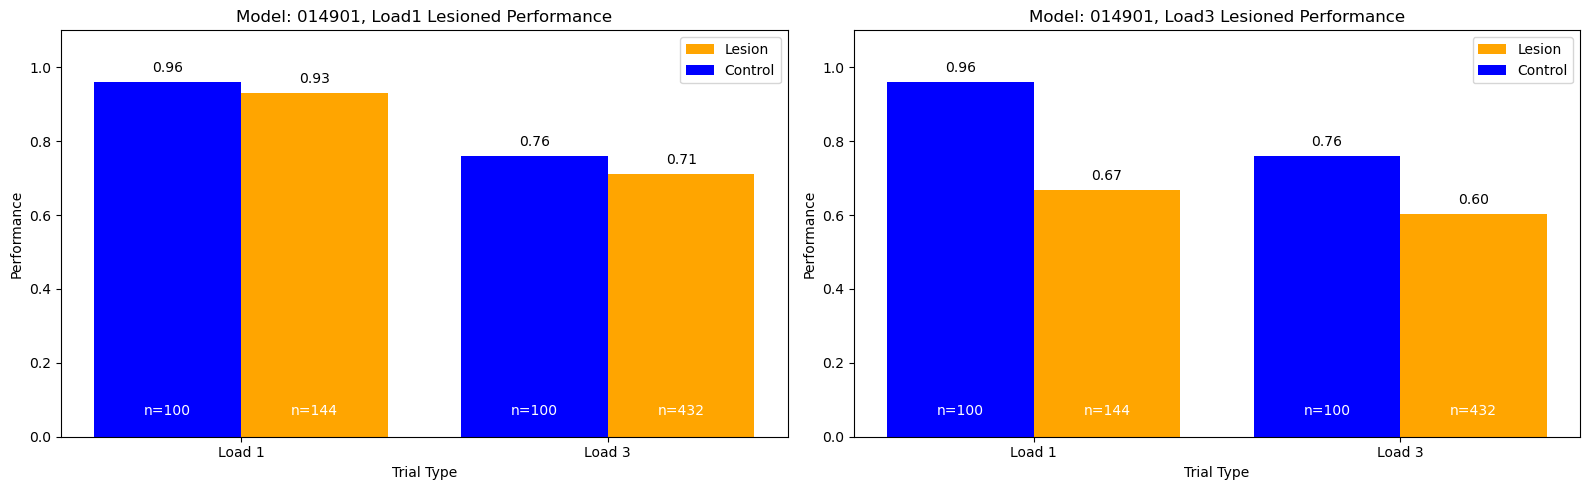

/tmp/ipykernel_860131/3173481761.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


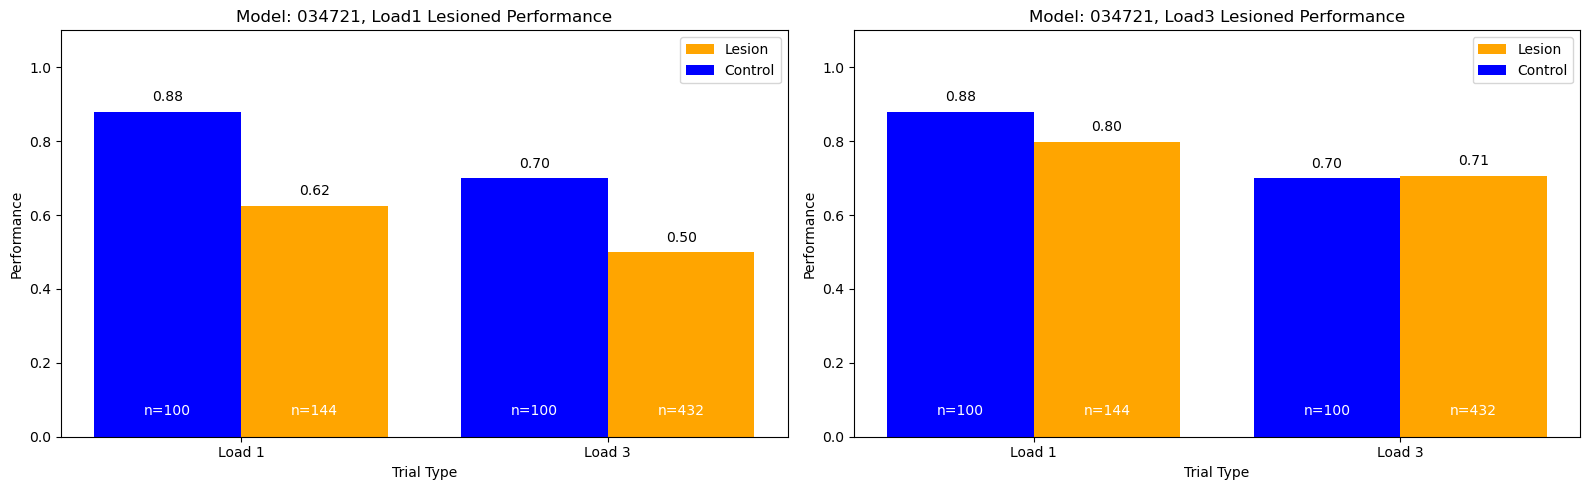

/tmp/ipykernel_860131/3173481761.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


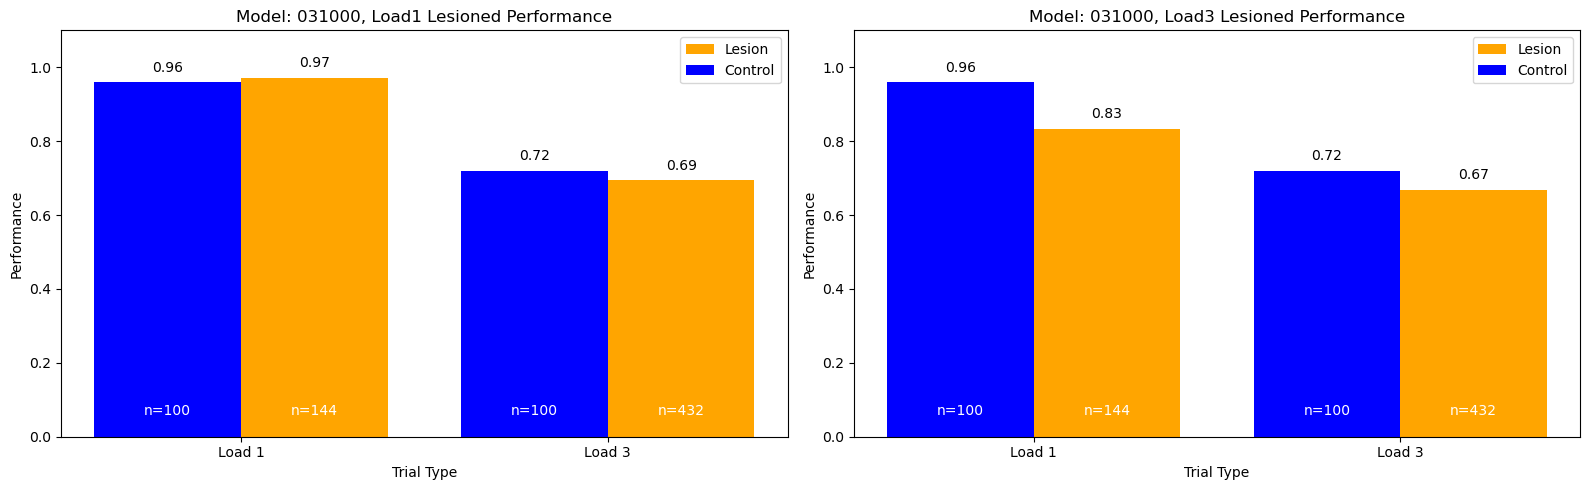

/tmp/ipykernel_860131/3173481761.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


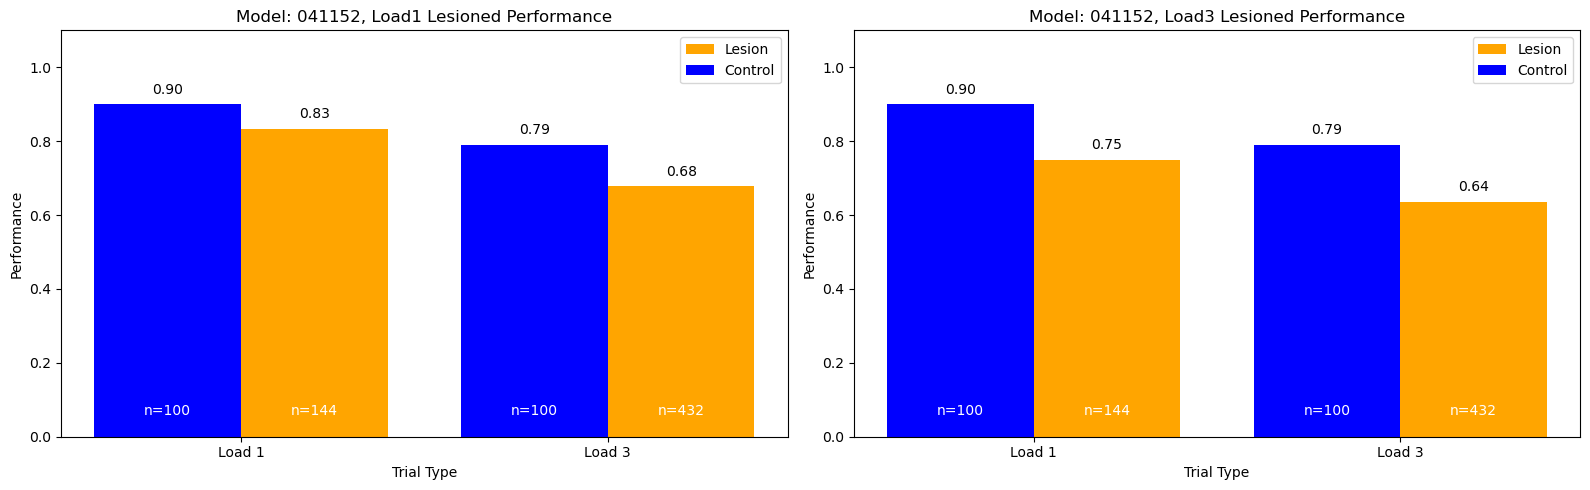

In [5]:
import matplotlib.gridspec as gridspec

condn_phrase = 'delay'
condn_num = 150

for model_name in model_names[:4]: # start with first 4 models for testing

    load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_stims",
                                all_models_dir=all_models_dir)
    load_selective = np.where(~np.isnan(load_tuning))[0]
    load_tuning = load_tuning[load_selective]

    trial_labels_ctrl, trial_perfs_ctrl, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels='balance_match',
        all_models_dir=all_models_dir
    )

    fig, axs = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
    for i, load_lesion in enumerate([1, 3]):
        other_labels = f'precomputed_lesion_maint_inh_loadpref_{load_lesion:g}'.format(load_lesion)
        trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(
            model_name, condn_phrase, condn_num,
            other_labels=other_labels,
            all_models_dir=all_models_dir
        )
        
        # compare performance of lesion vs control, split by load & match/mismatch
        perfs_lesion = []
        perfs_ctrl = []
        n_lesion_trials = []
        n_ctrl_trials = []
        x_labels = []
        for j, load in enumerate([1, 3]):
            lesion_trial_idxs = np.where((trial_labels[:, 0] == load))[0]
            perfs_lesion.append(np.mean(trial_perfs[lesion_trial_idxs]))
            n_lesion_trials.append(len(lesion_trial_idxs))
            ctrl_trial_idxs = np.where((trial_labels_ctrl[:, 0] == load))[0]
            perfs_ctrl.append(np.mean(trial_perfs_ctrl[ctrl_trial_idxs]))
            n_ctrl_trials.append(len(ctrl_trial_idxs))
            x_labels.append(f"Load {load}")
        axs[i].bar(np.arange(len(perfs_lesion))+0.2, perfs_lesion, width=0.4, color='orange', alpha=1, label='Lesion')
        axs[i].bar(np.arange(len(perfs_ctrl))-0.2, perfs_ctrl, width=0.4, color='blue', alpha=1, label='Control')
        # show n inside bars
        for j, (perf_lesion, perf_ctrl) in enumerate(zip(perfs_lesion, perfs_ctrl)):
            axs[i].text(j+0.2, perf_lesion + 0.02, f"{perf_lesion:.2f}", ha='center', va='bottom', fontsize=10, color='black')
            axs[i].text(j-0.2, perf_ctrl + 0.02, f"{perf_ctrl:.2f}", ha='center', va='bottom', fontsize=10, color='black')
            axs[i].text(j+0.2, 0.05, f"n={n_lesion_trials[j]}", ha='center', va='bottom', fontsize=10, color='white')
            axs[i].text(j-0.2, 0.05, f"n={n_ctrl_trials[j]}", ha='center', va='bottom', fontsize=10, color='white')
        axs[i].set_ylabel("Performance")
        axs[i].set_xlabel("Trial Type")
        axs[i].set_xticks(np.arange(len(perfs_lesion)))
        axs[i].set_xticklabels(x_labels, rotation=0, ha='center')
        axs[i].set_ylim(0, 1.1)
        axs[i].legend()
        axs[i].set_title(f"Model: {model_name[-6:]}, Load{load_lesion} Lesioned Performance")
    
    plt.tight_layout()
    plt.show()

# old

# Lesion by 100%

In [6]:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3'

model_paths = ['Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_041152.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_180002.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_233744.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_023239.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_043128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063647.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_153131.mat']

model_names = [os.path.basename(m)[:-4] for m in model_paths]

In [7]:
for model_name in model_names:
    
    model_dir = os.path.join(all_models_dir, model_name)
    stim1_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
    stim_selective = np.where(~np.isnan(stim1_stimtuning))[0]
    stim_tuning = stim1_stimtuning[stim_selective]
    
    unique_stims = np.unique(stim_tuning)
    for stim in unique_stims: # 0, 1, 2, 3
        neuron_idxs = stim_selective[stim_tuning == stim] # neuron indices for this specific stimulus
        u_all, trial_type_all = generate_stimset(pref=int(stim), settings=settings)

        grdm.generate_data(
            model_dir="/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3",
            pattern="*N_1000*.mat",
            n_repetitions=3,          # used by balance_stims (unused)
            eval_amp_threshold=0.7,
            workers=1,
            backend="torch",
            device="cuda",
            overwrite=False,
            mode="precomputed",     # or "balance_match" / "balance_stims"
            n_trials=50,              # used by balance_match (unused)
            loads=[1, 3],             # used by balance_match (unused)
            lesion="custom",
            lesion_inds=[(None, neuron_idxs)], # (postsyn, presyn)
            lesion_scale=0,
            lesion_tag=f"stim_lesion0_stimpref_{stim:g}",
            include_models=[model_name],
            u_all = u_all,
            trial_type_all = trial_type_all
        )

Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] skipping Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat, already saved
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] skipping Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat, already saved
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] skipping Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat, already saved
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] skipping Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat, already saved
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/ren

### analyze behavioral data

#### necessary functions

In [13]:
def get_stats(trial_labels, trial_perfs, stim_tuning, load):

    load_idxs = np.where(trial_labels[:,0] == load)[0]
    match_idxs = np.where(trial_labels[:,1] == 1)[0]
    mismatch_idxs = np.where(trial_labels[:,1] == -1)[0]

    # Define "pref shown" based on load
    if load == 1:
        pref_shown = np.where(trial_labels[:,2] == stim_tuning)[0]
    else:
        pref_shown = np.where(
            np.any(trial_labels[:,2:5] == stim_tuning, axis=1)
        )[0]

    pref_not_shown = np.setdiff1d(
        np.arange(len(trial_labels)),
        pref_shown
    )

    load_match_idxs = np.intersect1d(load_idxs, match_idxs)
    load_mismatch_idxs = np.intersect1d(load_idxs, mismatch_idxs)

    vals = [
        np.mean(trial_perfs[np.intersect1d(load_match_idxs, pref_shown)]),
        np.mean(trial_perfs[np.intersect1d(load_match_idxs, pref_not_shown)]),
        np.mean(trial_perfs[np.intersect1d(load_mismatch_idxs, pref_shown)]),
        np.mean(trial_perfs[np.intersect1d(load_mismatch_idxs, pref_not_shown)])
    ]

    ns = [
        len(np.intersect1d(load_match_idxs, pref_shown)),
        len(np.intersect1d(load_match_idxs, pref_not_shown)),
        len(np.intersect1d(load_mismatch_idxs, pref_shown)),
        len(np.intersect1d(load_mismatch_idxs, pref_not_shown))
    ]

    return vals, ns

In [14]:
def get_pref_probe_stats(trial_labels, trial_perfs, stim_tuning):

    load3_idxs = np.where(trial_labels[:,0] == 3)[0]
    match_idxs = np.where(trial_labels[:,1] == 1)[0]

    pref_shown = np.where(
        np.any(trial_labels[:,2:5] == stim_tuning, axis=1)
    )[0]

    pref_probe = np.where(trial_labels[:,5] == stim_tuning)[0]
    pref_notprobe = np.where(trial_labels[:,5] != stim_tuning)[0]

    match_pref = np.intersect1d(
        np.intersect1d(load3_idxs, match_idxs),
        pref_shown
    )

    match_pref_probe = np.intersect1d(match_pref, pref_probe)
    match_pref_notprobe = np.intersect1d(match_pref, pref_notprobe)

    vals = [
        np.mean(trial_perfs[match_pref_probe]),
        np.mean(trial_perfs[match_pref_notprobe])
    ]

    ns = [
        len(match_pref_probe),
        len(match_pref_notprobe)
    ]

    return vals, ns

In [15]:
def get_means_ns(trial_labels, trial_perfs, stim_tuning):

    load3 = trial_labels[:,0] == 3
    match = trial_labels[:,1] == 1
    mismatch = trial_labels[:,1] == -1

    prefs = {
        'Pref1': trial_labels[:,2] == stim_tuning,
        'Pref2': trial_labels[:,3] == stim_tuning,
        'Pref3': trial_labels[:,4] == stim_tuning,
    }

    prefs['NoPref'] = ~np.logical_or.reduce(list(prefs.values()))

    conds = {
        f'Match\n{name}': load3 & match & mask
        for name, mask in prefs.items()
    }

    conds.update({
        f'Mismatch\n{name}': load3 & mismatch & mask
        for name, mask in prefs.items()
    })

    means = [trial_perfs[m].mean() for m in conds.values()]
    ns = [m.sum() for m in conds.values()]

    return list(conds.keys()), means, ns

In [16]:
def plot_grouped_bars(ax, ctrl_vals, lesion_vals,
                      ctrl_ns, lesion_ns,
                      labels, title,
                      ylabel='Perf',
                      show_legend=False,
                      fontsize=9,
                      tick_rotation=0):

    x = np.arange(len(labels))
    width = 0.35

    ax.bar(x - width/2, ctrl_vals, width, color='tab:blue', label='Control')
    ax.bar(x + width/2, lesion_vals, width, color='tab:orange', label='Lesion')

    ha = 'right' if tick_rotation > 0 else 'center'
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=fontsize, rotation=tick_rotation, ha=ha)
    ax.tick_params(axis='y', labelsize=fontsize)
    ax.set_title(title, fontsize=fontsize + 1, pad=2)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.set_ylim(0, 1.18)

    # value labels on top of bars
    for xpos, val in zip(x - width/2, ctrl_vals):
        ax.text(xpos, val + 0.01, f'{val:.2f}',
                ha='center', va='bottom', fontsize=max(fontsize - 2, 5))
    for xpos, val in zip(x + width/2, lesion_vals):
        ax.text(xpos, val + 0.01, f'{val:.2f}',
                ha='center', va='bottom', fontsize=max(fontsize - 2, 5))

    # n= as white text centered inside bars
    for xpos, n, val in zip(x - width/2, ctrl_ns, ctrl_vals):
        if val > 0.1:
            ax.text(xpos, val / 2, f'n={n}',
                    ha='center', va='center',
                    fontsize=max(fontsize - 3, 5), color='white')
    for xpos, n, val in zip(x + width/2, lesion_ns, lesion_vals):
        if val > 0.1:
            ax.text(xpos, val / 2, f'n={n}',
                    ha='center', va='center',
                    fontsize=max(fontsize - 3, 5), color='white')

    if show_legend:
        ax.legend(fontsize=fontsize, loc='lower right')

#### analysis

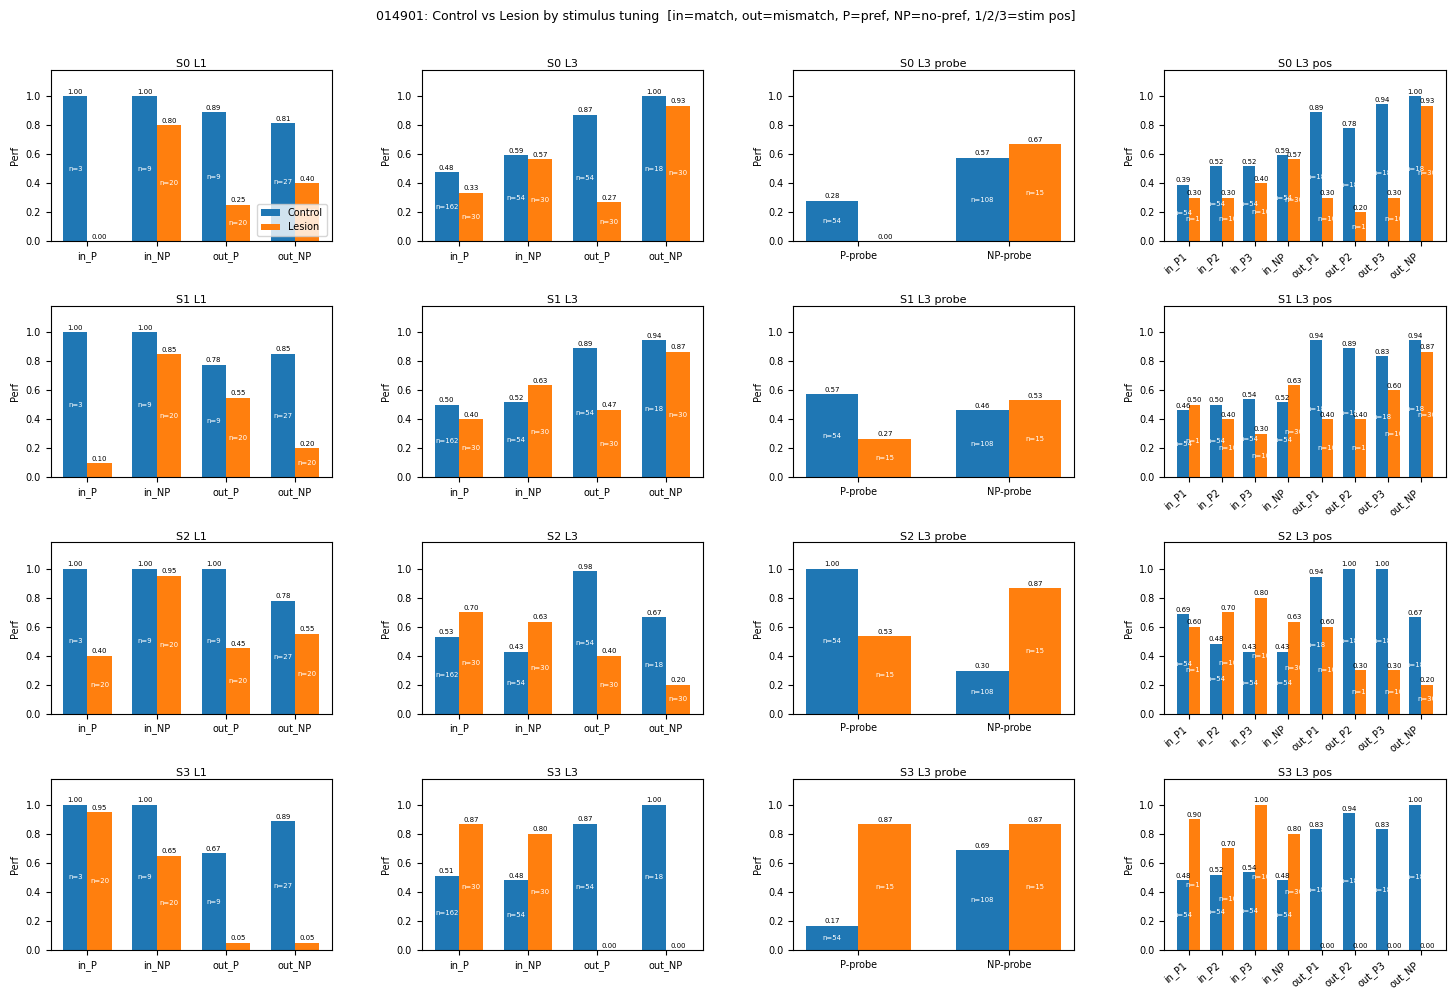

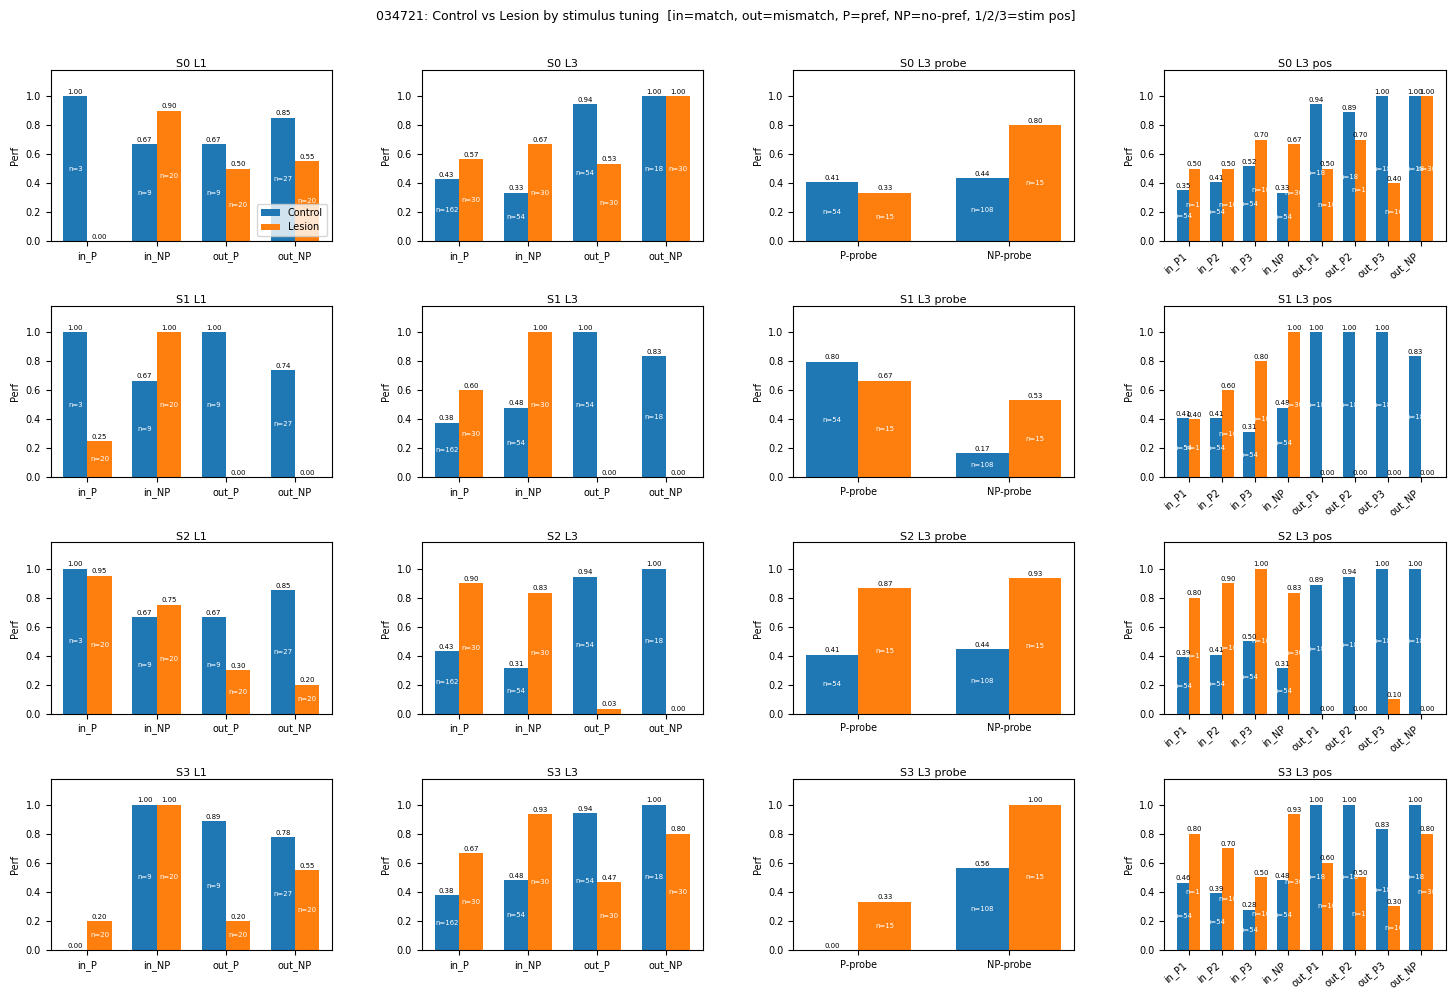

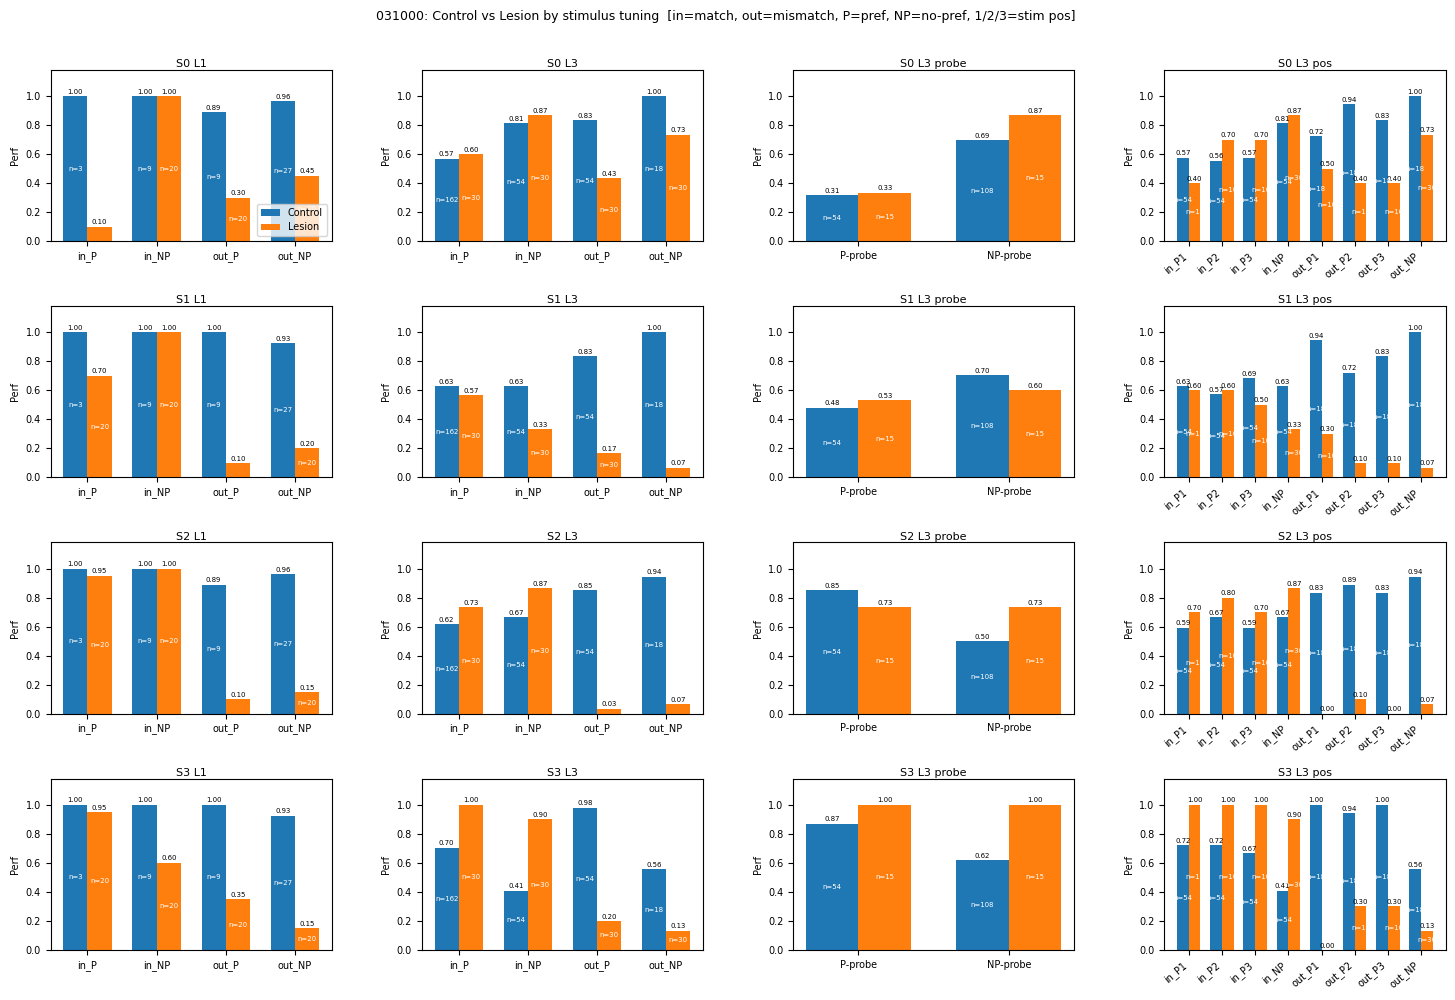

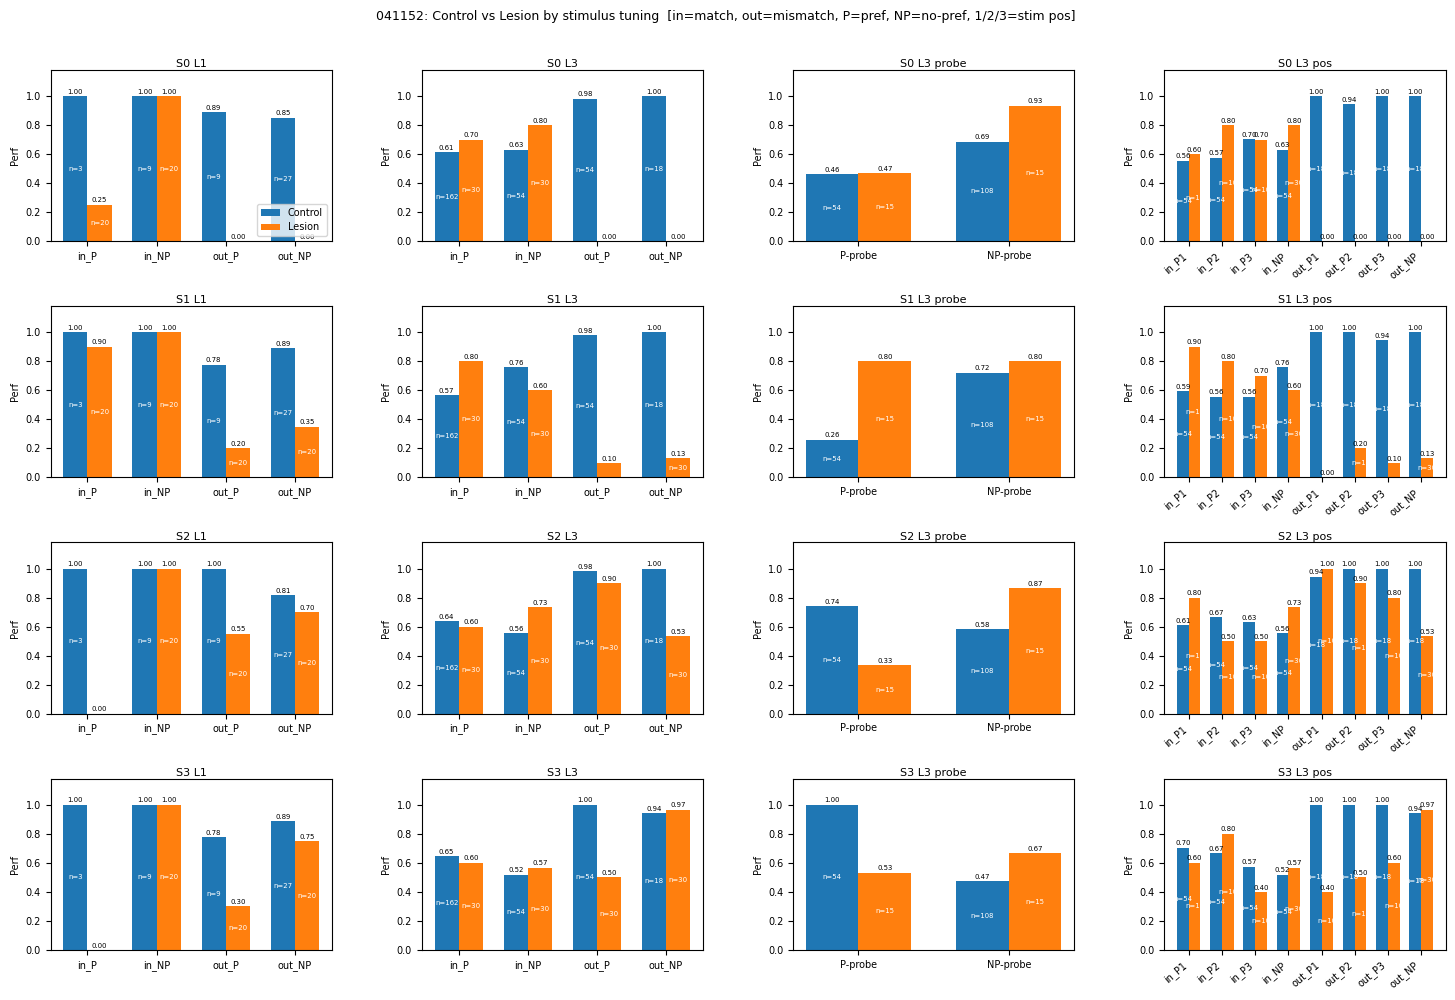

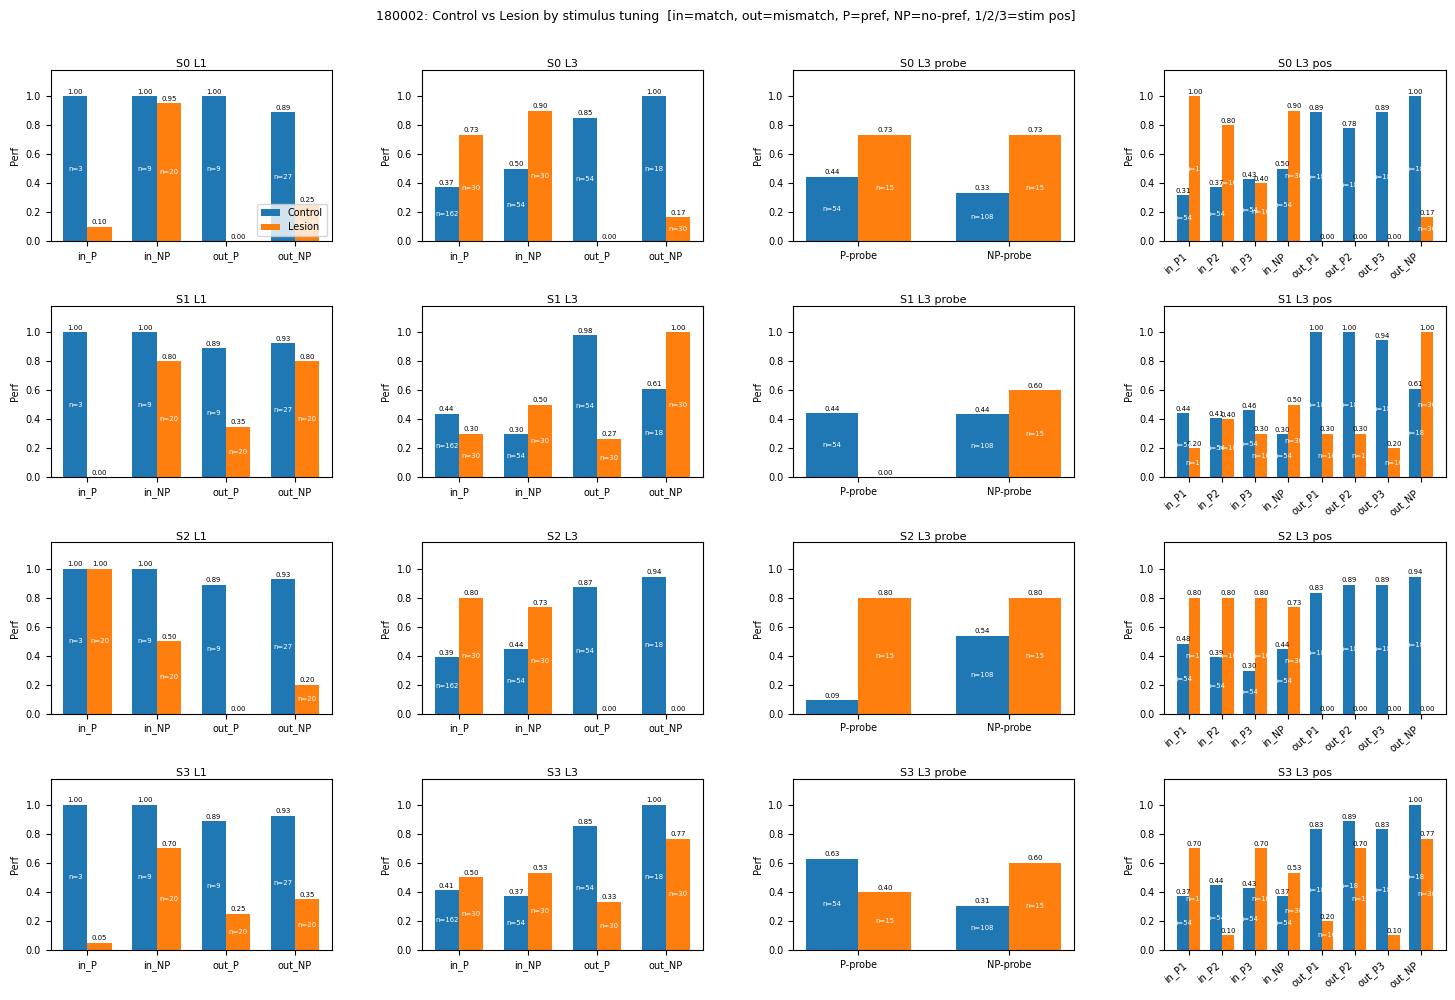

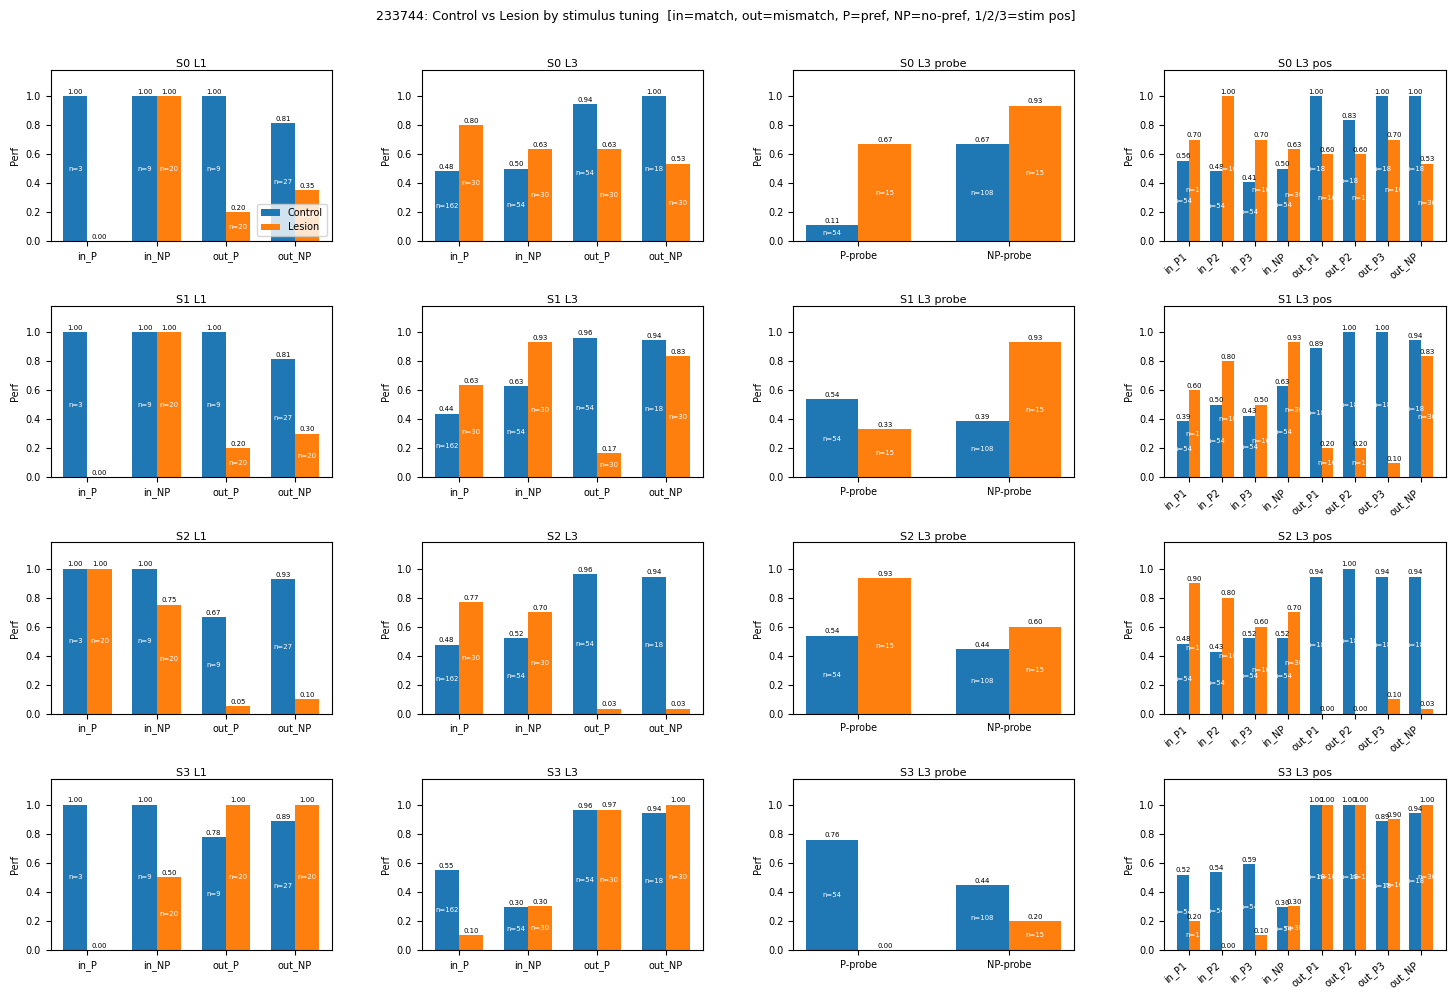

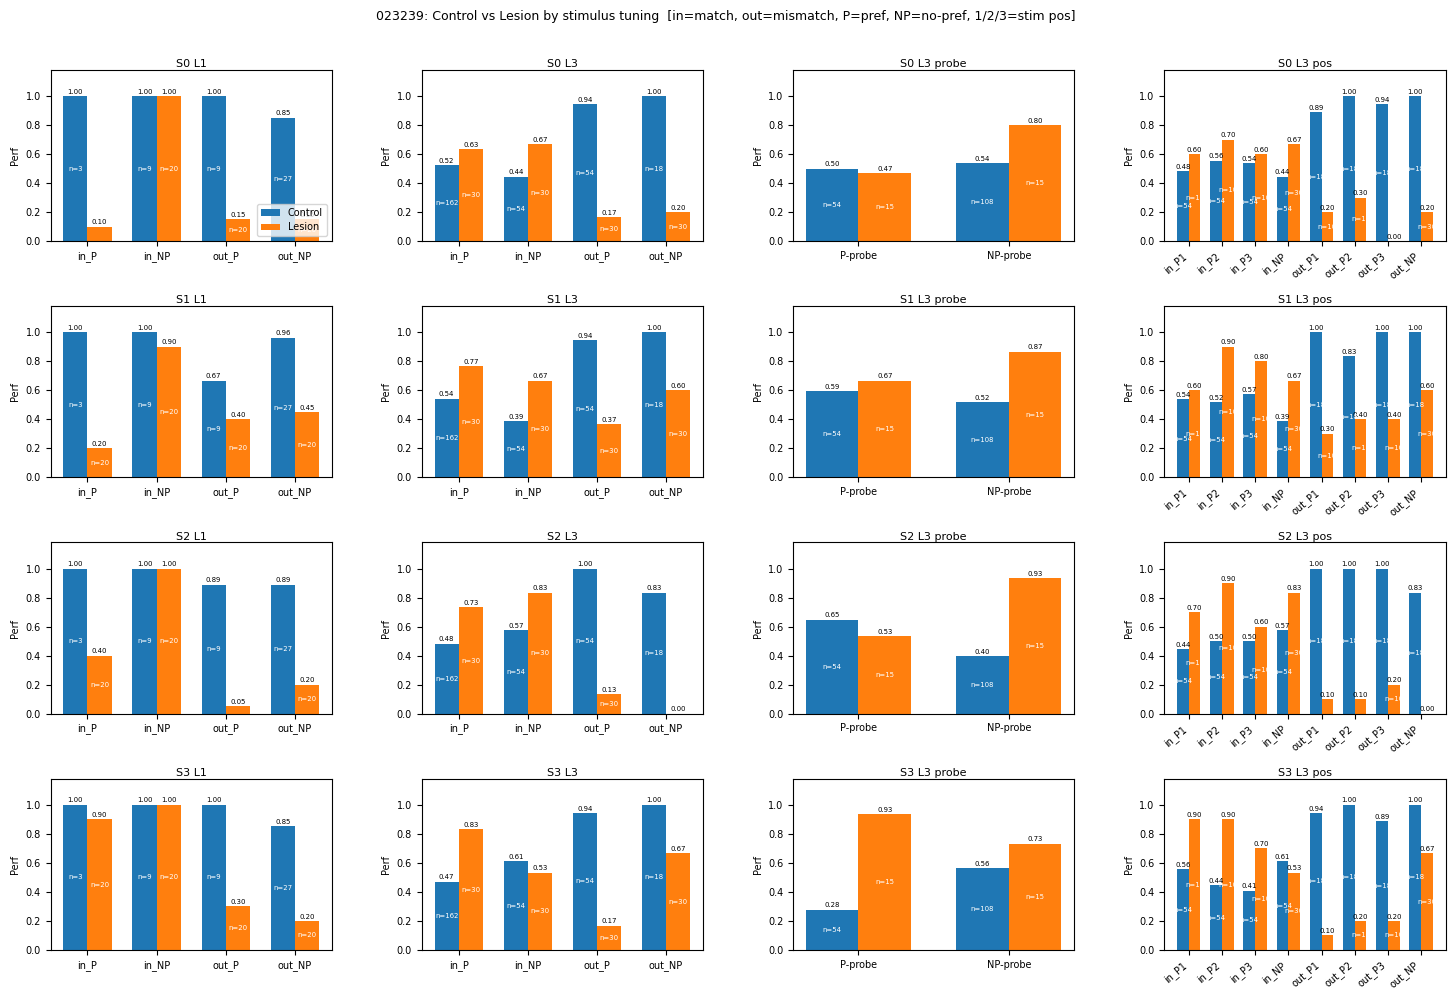

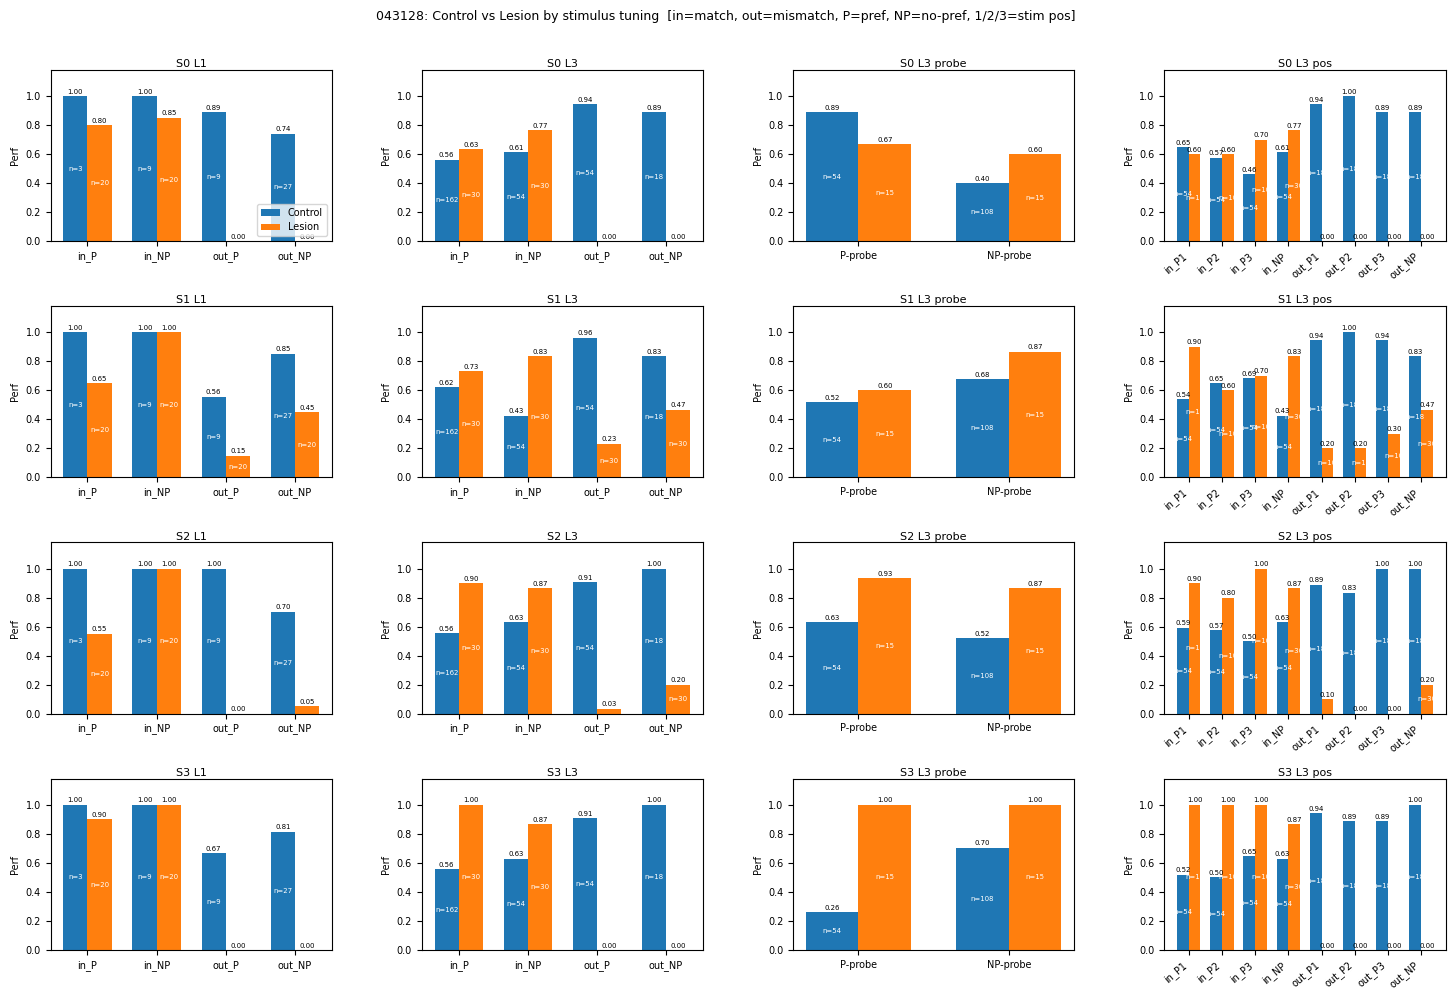

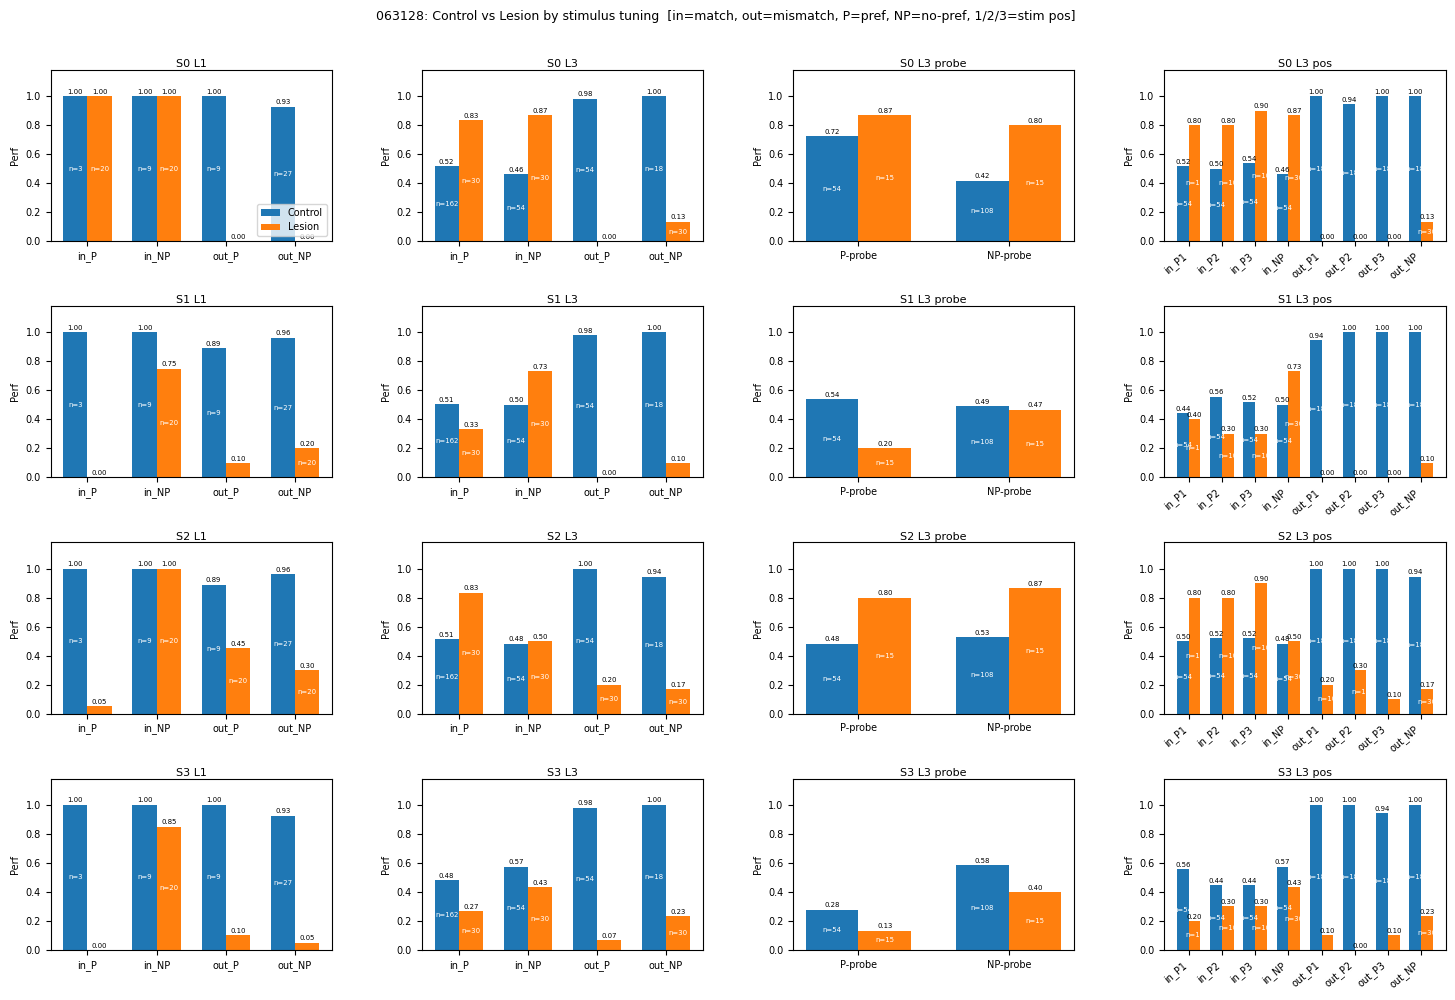

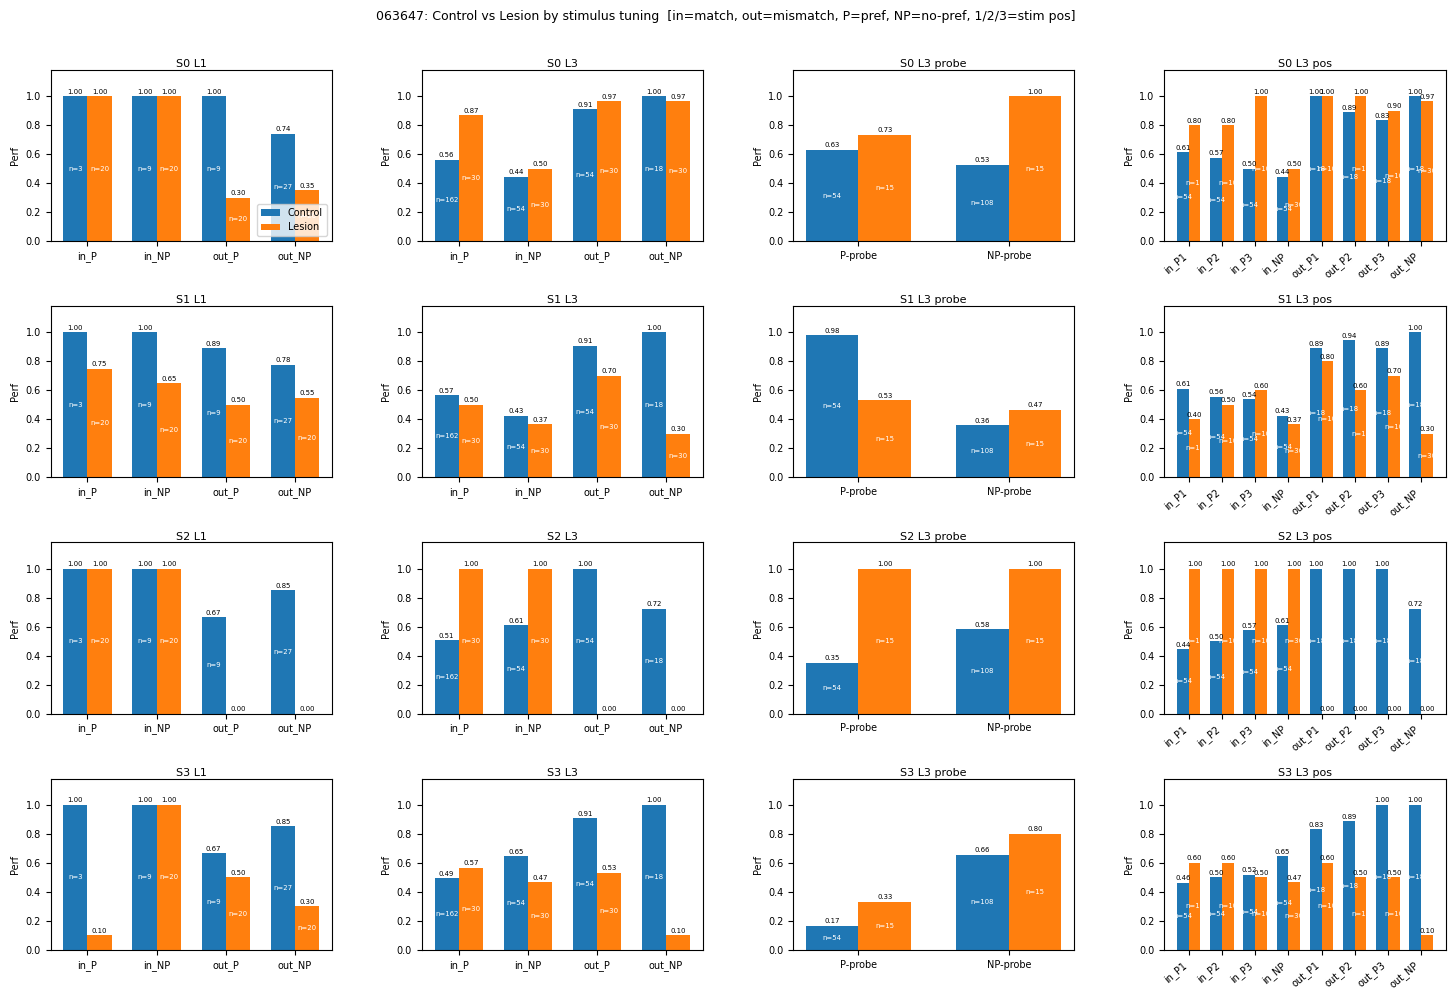

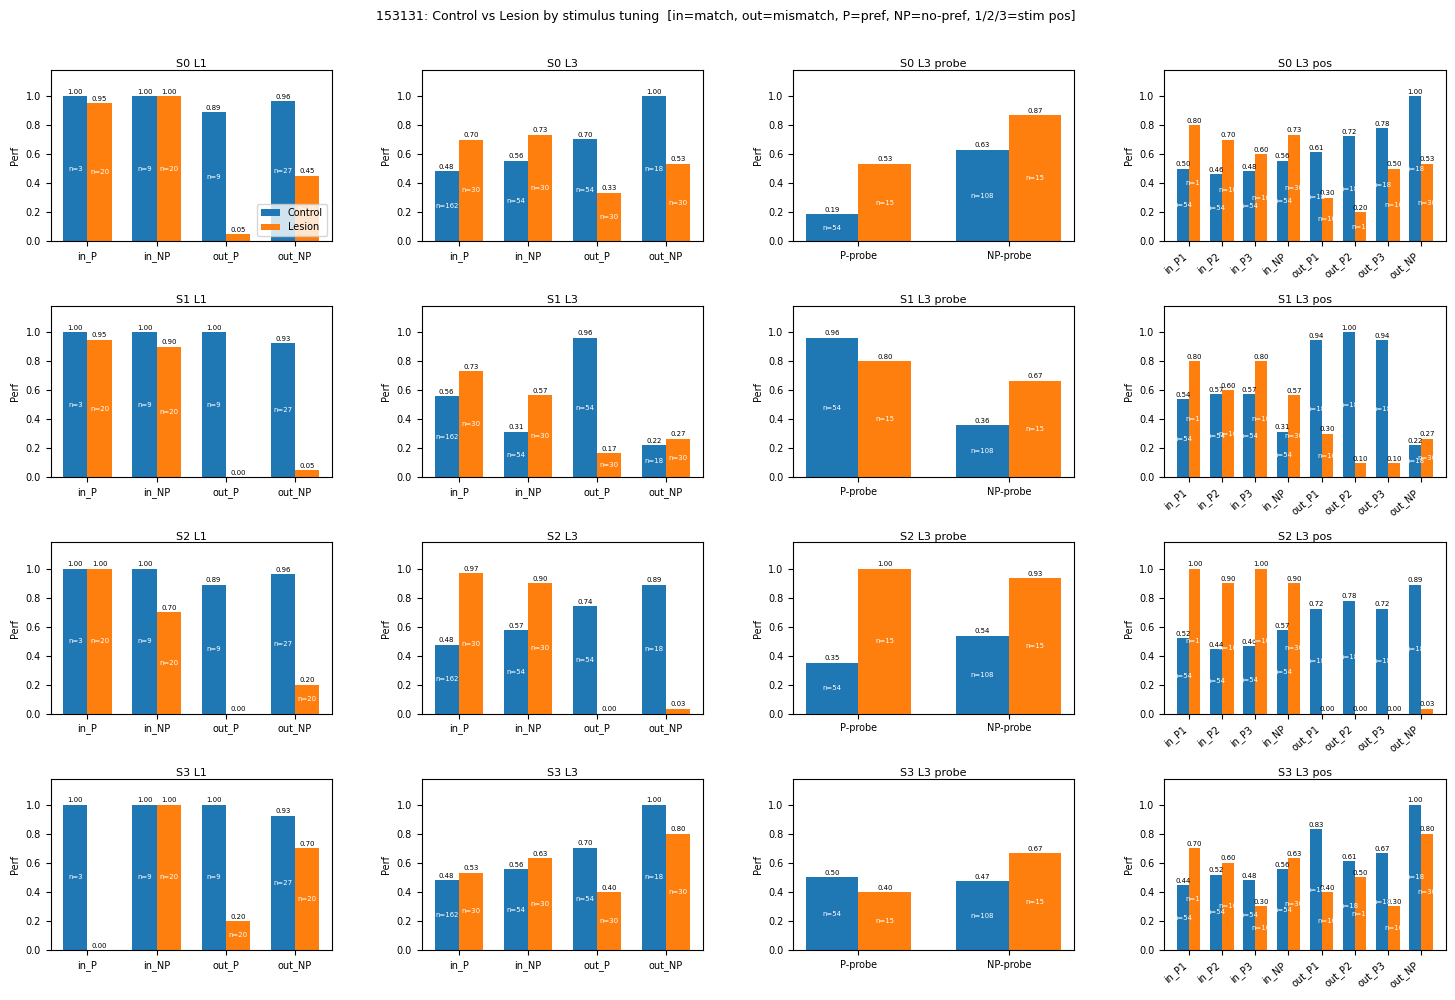

In [18]:
import matplotlib.gridspec as gridspec

condn_phrase = 'delay'
condn_num = 150

LOAD_LABELS = ['in_P', 'in_NP', 'out_P', 'out_NP']
PROBE_LABELS = ['P-probe', 'NP-probe']
POS_LABEL_MAP = {
    'Match\nPref1': 'in_P1', 'Match\nPref2': 'in_P2',
    'Match\nPref3': 'in_P3', 'Match\nNoPref': 'in_NP',
    'Mismatch\nPref1': 'out_P1', 'Mismatch\nPref2': 'out_P2',
    'Mismatch\nPref3': 'out_P3', 'Mismatch\nNoPref': 'out_NP',
}

FS = 7

for model_name in model_names:

    model_dir = os.path.join(all_models_dir, model_name)
    stim1_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
    stim_selective = np.where(~np.isnan(stim1_stimtuning))[0]

    trial_labels_ctrl, trial_perfs_ctrl, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels='balance_stim',
        all_models_dir=all_models_dir
    )

    # 4 horizontal strips, one per stimulus; each strip has 4 panels
    fig = plt.figure(figsize=(18, 10))
    gs_outer = gridspec.GridSpec(4, 1, figure=fig, hspace=0.38, top=0.92, bottom=0.04)

    for stim_tuning in [0, 1, 2, 3]:
        gs_inner = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs_outer[stim_tuning], wspace=0.32)
        row_axs  = [fig.add_subplot(gs_inner[0, c]) for c in range(4)]

        other_labels = f'precomputed_lesion_stim_lesion0_stimpref_{stim_tuning}'
        trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(
            model_name, condn_phrase, condn_num,
            other_labels=other_labels,
            all_models_dir=all_models_dir
        )

        # col 0: load=1
        ctrl_vals, ctrl_ns = get_stats(trial_labels_ctrl, trial_perfs_ctrl, stim_tuning, load=1)
        lesion_vals, lesion_ns = get_stats(trial_labels, trial_perfs, stim_tuning, load=1)
        plot_grouped_bars(
            row_axs[0], ctrl_vals, lesion_vals, ctrl_ns, lesion_ns,
            LOAD_LABELS, f'S{stim_tuning} L1',
            fontsize=FS, show_legend=(stim_tuning == 0)
        )

        # col 1: load=3
        ctrl_vals, ctrl_ns = get_stats(trial_labels_ctrl, trial_perfs_ctrl, stim_tuning, load=3)
        lesion_vals, lesion_ns = get_stats(trial_labels, trial_perfs, stim_tuning, load=3)
        plot_grouped_bars(
            row_axs[1], ctrl_vals, lesion_vals, ctrl_ns, lesion_ns,
            LOAD_LABELS, f'S{stim_tuning} L3',
            fontsize=FS
        )

        # col 2: load=3 match — pref as probe?
        ctrl_vals, ctrl_ns = get_pref_probe_stats(trial_labels_ctrl, trial_perfs_ctrl, stim_tuning)
        lesion_vals, lesion_ns = get_pref_probe_stats(trial_labels, trial_perfs, stim_tuning)
        plot_grouped_bars(
            row_axs[2], ctrl_vals, lesion_vals, ctrl_ns, lesion_ns,
            PROBE_LABELS, f'S{stim_tuning} L3 probe',
            fontsize=FS
        )

        # col 3: load=3 — pref stim position (8 bars)
        raw_labels, ctrl_vals, ctrl_ns = get_means_ns(trial_labels_ctrl, trial_perfs_ctrl, stim_tuning)
        _, lesion_vals, lesion_ns = get_means_ns(trial_labels, trial_perfs, stim_tuning)
        short_labels = [POS_LABEL_MAP.get(l, l) for l in raw_labels]
        plot_grouped_bars(
            row_axs[3], ctrl_vals, lesion_vals, ctrl_ns, lesion_ns,
            short_labels, f'S{stim_tuning} L3 pos',
            fontsize=FS, tick_rotation=40
        )

    fig.suptitle(
        f'{model_name[-6:]}: Control vs Lesion by stimulus tuning  '
        f'[in=match, out=mismatch, P=pref, NP=no-pref, 1/2/3=stim pos]',
        fontsize=9
    )
    plt.show()